# DAB Converter â€” PCB Component Selection (Report 3)

### Design Specifications

| Property | Symbol | Value | Unit |
|---|---|---|---|
| Nominal output power | $P_\mathrm{out,nom}$ | 50 | W |
| Nominal input voltage | $V_\mathrm{in,nom}$ | 50 | V |
| Minimum input voltage | $V_\mathrm{in,min}$ | 30 | V |
| Maximum input voltage | $V_\mathrm{in,max}$ | 60 | V |
| Output voltage | $V_\mathrm{out}$ | 12 | V |
| Output voltage ripple (rel.) | $\Delta V_\mathrm{out,pp,rel}$ | 2 | % |
| Switching frequency | $f_\mathrm{sw}$ | 80 | kHz |
| Auxiliary output voltage | $V_\mathrm{aux,out}$ | 18 | V |
| Auxiliary output power | $P_\mathrm{aux,out}$ | 5 | W |

In [1]:
import numpy as np
import matplotlib.pyplot as plt

plt.rcParams['figure.dpi'] = 150
plt.rcParams['savefig.dpi'] = 300
plt.rcParams['font.size'] = 10
plt.rcParams['axes.linewidth'] = 1.2
plt.rcParams['grid.alpha'] = 0.3
plt.rcParams['lines.linewidth'] = 2

In [2]:
# ============================================================
# GIVEN PARAMETERS (from Reports 1 and 2)
# ============================================================

# DAB converter specs
P_out       = 50.0      # Nominal output power [W]
V_in_nom    = 50.0      # Nominal input voltage [V]
V_in_min    = 30.0      # Minimum input voltage [V]
V_in_max    = 60.0      # Maximum input voltage [V]
V_out       = 12.0      # Output voltage [V]
dV_out_rel  = 0.02      # Output voltage ripple (relative)
f_sw        = 80e3      # Switching frequency [Hz]
T_sw        = 1/f_sw    # Switching period [s]
V_aux_out   = 18.0      # Auxiliary output voltage [V]
P_aux_out   = 5.0       # Auxiliary output power [W]

# From Report 1
C_in_holdup  = 625e-6   # Input holdup capacitance [F]
C_in_ripple  = 10.14e-6 / 2  # Input ripple capacitance [F] (/2 comes from error in rapport1)
C_DCblock    = 15.2e-6  # DC blocking capacitance [F]
C_out_min    = 152.72e-6 *2 # Output capacitance [F] (*2 comes from error in rapport 1)
R_discharge  = 28.61e3  # Discharge resistor [Ohm]

# From Report 2 (transformer design)
L            = 26.04e-6 # DAB inductance [H]
N1, N2, Naux = 25, 6, 9 # Turns
n_real       = N1/N2    # Primary-to-secondary turns ratio
n_aux_real   = Naux/N1  # Auxiliary-to-primary turns ratio

# From Report 2, Q3: peak and RMS inductor current at V_in_min
i_delta      = 3.604    # Peak inductor current (V_in_min) [A]
I1_RMS       = 2.015    # Primary winding RMS current (V_in_min) [A]

# Gate driver parameters (UCC27288)
VDD          = 12.0     # Gate drive voltage [V]
V_D_boot     = 0.9      # Bootstrap diode forward drop [V]
V_UV_boot    = 9.6      # Bootstrap UVLO rising threshold [V]
I_Q_driver   = 2.1e-3   # Gate driver quiescent current [A]
I_HB_max     = 0.4e-3   # HB quiescent current, max (from datasheet Table 6.5) [A]
I_HBS_max    = 50e-6    # HB-to-VSS quiescent current, max (V_HS=V_HB=100V) [A]
I_DD_max     = 0.45e-3  # VDD quiescent current, max (from datasheet Table 6.5) [A]
R_GD_R       = 4.1      # Average internal gate drive resistance (used in power calc) [Ohm]
R_HOH_drv    = 4.2      # HS pull-up   internal resistance (from datasheet) [Ohm]
R_HOL_drv    = 4.0      # HS pull-down internal resistance (from datasheet) [Ohm]
R_LOH_drv    = 4.2      # LS pull-up   internal resistance (from datasheet) [Ohm]
R_LOL_drv    = 4.0      # LS pull-down internal resistance (from datasheet) [Ohm]
theta_JA_drv = 118.3    # Gate driver thermal resistance, R_thetaJA (SOIC-8, from datasheet Section 6.4) [C/W]
T_J_max_drv  = 140.0    # Gate driver max junction temperature (from datasheet Section 6.3) [C]
D_min        = 0.05     # Minimum duty cycle during soft-start

# INA201 current sense amplifier
Gain_INA     = 50.0     # INA201 voltage gain [V/V]
V_s          = 3.3      # Supply voltage for INA201 and op-amp [V]
I_Q_INA_max  = 1.8e-3   # INA201 max quiescent current [A]  (from datasheet Table, V_S=12V)
I_sc_INA     = 16.17e-3  # INA201 output short-circuit current [A]  (from datasheet graph, -40C, V_S=3.3V)
ADC_bits     = 12       # ADC resolution [bits]
ADC_Vref     = 3.0      # ADC reference voltage [V]

# MCP6241 op-amp
I_Q_MCP      = 50e-6    # MCP6241 quiescent current [A]

# LED (WP710A10LGD green)
V_F_LED      = 1.9      # LED forward voltage [V]
I_LED_target = 2e-3     # Target LED current [A]

# UA78L12ACDR (12V LDO)
I_max_LDO12  = 100e-3   # Maximum output current of UA78L12 [A]

print('Parameters loaded.')
print(f'T_sw = {T_sw*1e6:.2f} us')
print(f'n_real = {n_real:.4f}  (target {N1}/{N2})')
print(f'n_aux  = {n_aux_real:.4f}  (target {Naux}/{N1})')
print(f'V_aux  = {n_aux_real*V_in_nom:.1f} V')

Parameters loaded.
T_sw = 12.50 us
n_real = 4.1667  (target 25/6)
n_aux  = 0.3600  (target 9/25)
V_aux  = 18.0 V


---
## Q1 â€” Input electrolytic capacitor
Select from: 39D507G030FL6 (500ÂµF, 30V), MAL215236109E3 (10ÂµF, 400V), UHW2A681MHD (680ÂµF, 100V).

Requirements from Report 1: holdup C â‰¥ 625ÂµF, ripple C â‰¥ 10.14ÂµF, rated voltage â‰¥ V_in,max = 60V.

In [3]:
# Q1 â€” Input electrolytic capacitor
caps_Q1 = {
    '39D507G030FL6': (500e-6,  30),
    'MAL215236109E3': (10e-6, 400),
    'UHW2A681MHD':  (680e-6, 100),
}

print('Candidate    | C [uF]  | V_rated | C>=625uF? | V>=60V?')
print('-'*60)
for pn, (C, V) in caps_Q1.items():
    ok_C = C >= C_in_holdup
    ok_V = V >= V_in_max
    print(f'{pn:20s} | {C*1e6:6.0f}  | {V:7.0f} | {str(ok_C):9} | {str(ok_V)}')

C_in_elec = 680e-6
V_rated_Cin = 100
print(f'\n>>> Selected: UHW2A681MHD  C_in = {C_in_elec*1e6:.0f} uF, V_rated = {V_rated_Cin} V')

Candidate    | C [uF]  | V_rated | C>=625uF? | V>=60V?
------------------------------------------------------------
39D507G030FL6        |    500  |      30 | False     | False
MAL215236109E3       |     10  |     400 | False     | True
UHW2A681MHD          |    680  |     100 | True      | True

>>> Selected: UHW2A681MHD  C_in = 680 uF, V_rated = 100 V


---
## Q2 â€” Input ceramic capacitor
Electrolytic caps have high ESL, so they stop filtering effectively above ~10 kHz. Ceramic caps (near-zero ESL) handle the 80 kHz switching ripple. The required ceramic capacitance equals **C_in,ripple = 10.14 ÂµF** from Report 1.

**DC bias effect**: From the muRata datasheet C-V curve (GRM31CZ72A475KE11L, 4.7 ÂµF, 100 V):  
at 60 V DC bias â†’ cap change rate = **âˆ’79.6%** â†’ only **0.989 ÂµF** remains per cap.

Check whether â‰¤ 4 muRata caps (project maximum) can meet the requirement. If not, use the TDK C5750X7S2A226M280KB (22 ÂµF, 100 V, X7S, 2220 package).

In [4]:
# Q2 â€” Input ceramic capacitors
C_nom_murata   = 4.7e-6    # Nominal capacitance of GRM31CZ72A475KE11L [F]
cap_change_60V = -0.796    # Cap change rate at 60V from muRata datasheet C-V curve
C_eff_murata   = C_nom_murata * (1 + cap_change_60V)   # = 0.989 uF

N_murata_min   = int(np.ceil(C_in_ripple / C_eff_murata))

print('--- muRata GRM31CZ72A475KE11L @60V ---')
print(f'Nominal C             : {C_nom_murata*1e6:.1f} uF')
print(f'Cap change @60V       : {cap_change_60V*100:.1f}%  (from datasheet C-V curve)')
print(f'Effective C @60V      : {C_eff_murata*1e6:.3f} uF')
print(f'Caps needed           : {N_murata_min}  -> EXCEEDS 4-cap project limit')
print()

# muRata requires 11 caps -> exceeds 4-cap limit
# Switch to TDK C5750X7S2A226M280KB (22 uF, 100V, X7S, 2220 package)
C_nom_TDK      = 22e-6
cap_change_TDK = -0.60     # Cap change rate at 60V from TDK datasheet DC bias curve
C_eff_TDK      = C_nom_TDK * (1 + cap_change_TDK)

N_TDK_min      = int(np.ceil(C_in_ripple / C_eff_TDK))
C_total_TDK    = N_TDK_min * C_eff_TDK

print('--- TDK C5750X7S2A226M280KB @60V ---')
print(f'Nominal C             : {C_nom_TDK*1e6:.0f} uF')
print(f'Cap change @60V       : {cap_change_TDK*100:.0f}%  (from TDK datasheet DC bias curve)')
print(f'Effective C @60V      : {C_eff_TDK*1e6:.1f} uF')
print(f'Required C_in,ceramic : {C_in_ripple*1e6:.2f} uF')
print(f'Caps needed           : {N_TDK_min}  (<= 4 âœ“)')
print(f'Total C @60V          : {C_total_TDK*1e6:.1f} uF  (>= {C_in_ripple*1e6:.2f} uF âœ“)')
print()
print(f'>>> Selected: {N_TDK_min}x TDK C5750X7S2A226M280KB in parallel')
print(f'    C_selected @60V = {C_total_TDK*1e6:.1f} uF')

# Store for later use
C_eff_ceramic_in = C_eff_TDK
N_ceramic_in     = N_TDK_min

--- muRata GRM31CZ72A475KE11L @60V ---
Nominal C             : 4.7 uF
Cap change @60V       : -79.6%  (from datasheet C-V curve)
Effective C @60V      : 0.959 uF
Caps needed           : 6  -> EXCEEDS 4-cap project limit

--- TDK C5750X7S2A226M280KB @60V ---
Nominal C             : 22 uF
Cap change @60V       : -60%  (from TDK datasheet DC bias curve)
Effective C @60V      : 8.8 uF
Required C_in,ceramic : 5.07 uF
Caps needed           : 1  (<= 4 âœ“)
Total C @60V          : 8.8 uF  (>= 5.07 uF âœ“)

>>> Selected: 1x TDK C5750X7S2A226M280KB in parallel
    C_selected @60V = 8.8 uF


---
## Q3 — Input discharge resistor
From Report 1: discharge time < 60 s (cap to 5% of initial = factor 1/20).

The discharge resistor must use the **total nominal capacitance** on the input bus, because the ceramic caps recover their nominal capacitance as the bus voltage drops toward 0 V during discharge. The ceramics selected in Q2 are rated at 22 µF nominal, so:

1619C_{total} = C_{elec} + N_{ceram} \cdot C_{nom,ceram} = 680\,\mu	ext{F} + 2 	imes 22\,\mu	ext{F} = 724\,\mu	ext{F}1619

1619R_{max} = rac{t_{discharge}}{C_{total} \cdot \ln(20)} = rac{60}{724\,\mu	ext{F} \cdot \ln(20)} = 27.66\,	ext{k}\Omega1619

The closest E96 value **below** 27.66 kΩ is **27.4 kΩ → RMCF1206FT27K4** (from KIT-RMCF1206FT-05, 1206, 250 mW).

In [5]:
# Q3 — Input discharge resistor
import math

# Total input capacitance for discharge calculation:
# Ceramics recover nominal capacitance as voltage drops to 0V
C_elec      = 680e-6          # UHW2A681MHD nominal [F]
C_ceram_nom = 22e-6           # TDK C5750X7S2A226M280KB nominal [F]
N_ceram     = N_ceramic_in    # from Q2 result (= 1 with corrected C_in_ripple)
C_total_dis = C_elec + N_ceram * C_ceram_nom

t_spec      = 60.0            # discharge time spec [s]
ratio       = 20.0            # discharge to 5% (V_f = V_i/20)
R_dis_max   = t_spec / (C_total_dis * math.log(ratio))

print(f"C_total = {C_elec*1e6:.0f} + {N_ceram}x{C_ceram_nom*1e6:.0f} = {C_total_dis*1e6:.0f} uF")
print(f"R_max   = {t_spec:.0f} / ({C_total_dis*1e6:.0f}u * ln({ratio:.0f})) = {R_dis_max/1e3:.3f} kOhm")
print()

# Check E96 candidates from KIT-RMCF1206FT-05 (1206, 0.25W)
candidates = {27.4e3: "RMCF1206FT27K4 (1206, 250mW)",
              28.0e3: "RMCF1206FT28K0 (1206, 250mW)"}

print(f"{"Part":<35} | {"R [kOhm]":>10} | {"t_dis [s]":>10} | {"P @60V [mW]":>12} | OK?")
print("-"*80)
for R, name in candidates.items():
    t_dis = R * C_total_dis * math.log(ratio)
    P_act = V_in_max**2 / R
    ok    = (R <= R_dis_max) and (P_act <= 0.25)
    print(f"{name:<35} | {R/1e3:>10.1f} | {t_dis:>10.2f} | {P_act*1e3:>12.1f} | {"PASS ✓" if ok else "FAIL ✗"}")

R_dis_sel = 27.4e3
P_dis_sel = V_in_max**2 / R_dis_sel
t_dis_sel = R_dis_sel * C_total_dis * math.log(ratio)
print(f">>> Selected: RMCF1206FT27K4  ({R_dis_sel/1e3:.1f} kOhm, 1206, 250mW)")
print(f"    t_discharge = {t_dis_sel:.1f} s  < 60 s  ✓")
print(f"    P @ 60V     = {P_dis_sel*1e3:.1f} mW < 250 mW  ✓  ({250 - P_dis_sel*1e3:.0f} mW margin)")


C_total = 680 + 2x22 = 724 uF
R_max   = 60 / (724u * ln(20)) = 27.664 kOhm

Part                                |   R [kOhm] |  t_dis [s] |  P @60V [mW] | OK?
--------------------------------------------------------------------------------
RMCF1206FT27K4 (1206, 250mW)        |       27.4 |      59.43 |        131.4 | PASS ✓
RMCF1206FT28K0 (1206, 250mW)        |       28.0 |      60.73 |        128.6 | FAIL ✗
>>> Selected: RMCF1206FT27K4  (27.4 kOhm, 1206, 250mW)
    t_discharge = 59.4 s  < 60 s  ✓
    P @ 60V     = 131.4 mW < 250 mW  ✓  (119 mW margin)


---
## Q4 — DC blocking capacitor
Use TDK C5750X7S2A226M280KB (same part as Q2). The DC blocking cap sits in series with
the transformer primary; its purpose is to block DC, so at steady state the net DC voltage
across it is approximately **0 V** and it operates at its full nominal capacitance of **22 µF**.

Since 22 µF >> C_DCblock,min = 15.2 µF, **1 cap** is sufficient.

ESR at 80 kHz: **2.483 mΩ** (read from TDK datasheet impedance graph at 81.357 kHz).

In [6]:
# Q4 — DC blocking capacitor
# Part: TDK C5750X7S2A226M280KB (22 uF nominal, 100V)

# The DC blocking cap is in series with the primary; its DC bias is ~0V in steady state.
# -> operates at full nominal capacitance
C_eff_dcblock = C_nom_TDK      # = 22 uF at ~0V DC bias
N_dcblock     = 1
C_total_dcblock = N_dcblock * C_eff_dcblock

# ESR from TDK datasheet at ~80 kHz
ESR_TDK_80k = 2.483e-3         # [Ohm] at 81.357 kHz (from datasheet ESR graph)

# RMS current through DC blocking cap = primary winding RMS current (single cap, no split)
P_per_cap = ESR_TDK_80k * I1_RMS**2

print(f"Part              : TDK C5750X7S2A226M280KB")
print(f"ESR @ 80 kHz      : {ESR_TDK_80k*1e3:.3f} mOhm  (datasheet graph at 81.357 kHz)")
print(f"DC bias (SS)      : ~0 V  ->  C_eff = {C_eff_dcblock*1e6:.0f} uF (full nominal)")
print(f"Required C_DCblock: {C_DCblock*1e6:.1f} uF")
print(f"Number of caps    : {N_dcblock}  ->  {C_total_dcblock*1e6:.0f} uF >> {C_DCblock*1e6:.1f} uF  ✓")
print()
print(f"I1_RMS     : {I1_RMS:.3f} A")
print(f"P per cap  : {ESR_TDK_80k*1e3:.3f} mOhm x {I1_RMS:.3f}^2 = {P_per_cap*1e3:.2f} mW")
print(f">>> 1x TDK C5750X7S2A226M280KB, ESR = {ESR_TDK_80k*1e3:.3f} mOhm @80kHz, P = {P_per_cap*1e3:.2f} mW")


Part              : TDK C5750X7S2A226M280KB
ESR @ 80 kHz      : 2.483 mOhm  (datasheet graph at 81.357 kHz)
DC bias (SS)      : ~0 V  ->  C_eff = 22 uF (full nominal)
Required C_DCblock: 15.2 uF
Number of caps    : 1  ->  22 uF >> 15.2 uF  ✓

I1_RMS     : 2.015 A
P per cap  : 2.483 mOhm x 2.015^2 = 10.08 mW
>>> 1x TDK C5750X7S2A226M280KB, ESR = 2.483 mOhm @80kHz, P = 10.08 mW


---
## Q5 — Output capacitor
From Report 1: **C_out,min = 152.72 µF** at V_out = 12 V. The report instructs to use fewer capacitors.

Checking all large-value options in the Appendix against V_out = 12 V:

| Part | C_nom | V_rated | C @12V | N needed | Feasible? |
|---|---|---|---|---|---|
| Vishay MAL215097614E3 | 1000 µF | 25 V | ~1000 µF (electrolytic, no DC derating) | **1** | **Yes ✓** |
| KEMET C1206C226M4PACTU | 22 µF | 16 V | ~13 µF @12V (X7R ~60% retention) | 12 | No — >4 cap limit ✗ |
| TDK CGA5L1X7R1H106K160AC | 10 µF | 50 V | ~9 µF @12V | 17 | No — >4 cap limit ✗ |

**Selected: 1× Vishay MAL215097614E3** (1000 µF, 25 V, electrolytic).
Note: the Appendix flags this part with "Create footprint by your own" — a custom PCB footprint is required.

In [7]:
# Q5 — Output capacitor
V_out_req = V_out       # = 12 V

# Vishay MAL215097614E3: 1000 uF, 25V, electrolytic
# Electrolytics do not suffer significant DC bias capacitance derating
C_Vishay   = 1000e-6    # nominal [F]
V_Vishay   = 25         # rated voltage [V]
N_out      = 1
C_out_sel  = N_out * C_Vishay

# Ceramic alternatives from Appendix (all fail the 4-cap limit at 12V):
C_KEMET22  = 22e-6;  V_KEMET22  = 16;  N_KEMET = int(__import__("math").ceil(C_out_min / (C_KEMET22 * 0.60)))
C_TDK10    = 10e-6;  V_TDK10    = 50;  N_TDK10 = int(__import__("math").ceil(C_out_min / (C_TDK10  * 0.90)))

print(f"Required C_out,min = {C_out_min*1e6:.2f} uF,  V_out = {V_out_req:.0f} V")
print()
print(f"Option A: Vishay MAL215097614E3  (1000 uF, 25V electrolytic)")
print(f"  C_sel  = {C_out_sel*1e6:.0f} uF  >> {C_out_min*1e6:.2f} uF  ✓")
print(f"  V_rated = {V_Vishay} V  > {V_out_req:.0f} V  ✓")
print(f"  N = {N_out} cap  ✓  (min caps, as instructed)")
print()
print(f"Option B: KEMET C1206C226M4PACTU  (22 uF, 16V ceramic, ~60% @12V -> 13.2 uF)")
print(f"  N needed = {N_KEMET}  -> EXCEEDS 4-cap limit ✗")
print()
print(f"Option C: TDK CGA5L1X7R1H106K160AC  (10 uF, 50V ceramic, ~90% @12V -> 9 uF)")
print(f"  N needed = {N_TDK10}  -> EXCEEDS 4-cap limit ✗")
print()
print(f">>> Selected: {N_out}x Vishay MAL215097614E3")
print(f"    C_selected = {C_out_sel*1e6:.0f} uF,  V_rated = {V_Vishay} V")
print(f"    Note: custom PCB footprint required (flagged in Appendix)")


Required C_out,min = 152.72 uF,  V_out = 12 V

Option A: Vishay MAL215097614E3  (1000 uF, 25V electrolytic)
  C_sel  = 1000 uF  >> 152.72 uF  ✓
  V_rated = 25 V  > 12 V  ✓
  N = 1 cap  ✓  (min caps, as instructed)

Option B: KEMET C1206C226M4PACTU  (22 uF, 16V ceramic, ~60% @12V -> 13.2 uF)
  N needed = 12  -> EXCEEDS 4-cap limit ✗

Option C: TDK CGA5L1X7R1H106K160AC  (10 uF, 50V ceramic, ~90% @12V -> 9 uF)
  N needed = 17  -> EXCEEDS 4-cap limit ✗

>>> Selected: 1x Vishay MAL215097614E3
    C_selected = 1000 uF,  V_rated = 25 V
    Note: custom PCB footprint required (flagged in Appendix)


---
## Q6 — Gate charge $ from datasheet
- **Primary MOSFET**: PHP18NQ11T (Nexperia), V_DS = 110 V, I_D = 13 A
- **Secondary MOSFET**: IRLB8743PbF (Infineon), V_DS = 30 V, I_D = 110 A

**PHP18NQ11T (primary):** The graph y-axis only reaches 10 V. Use the V_DD = 80 V curve
(closest to V_in,max = 60 V). Two points are read from the post-plateau linear region
and the slope is extrapolated to V_GS = 12 V:
- Point 1: Q_g = 11.92 nC @ V_GS = 5 V
- Point 2: Q_g = 19.23 nC @ V_GS = 9 V
- Slope = (19.23 − 11.92) / (9 − 5) = 1.8275 nC/V
- Extrapolated to 12 V: Q_g = 19.23 + 1.8275 × (12 − 9) = **24.71 nC**

**IRLB8743PbF (secondary):** Graph shows V_DS = 15 V and 24 V curves. Use V_DS = 15 V
(closest to V_out = 12 V). Both curves are very close. Read directly at V_GS = 12 V:
- Q_g = **88.24 nC**

In [8]:
# Q6 — Gate charge

# PHP18NQ11T (primary): extrapolate post-plateau to V_GS = 12V
# Two points read from V_DD = 80V curve:
Q1_V, Q1_nC = 5.0,  11.92   # (V_GS [V], Q_g [nC])
Q2_V, Q2_nC = 9.0,  19.23

slope_nC_per_V = (Q2_nC - Q1_nC) / (Q2_V - Q1_V)
Q_g_pri_nC     = Q2_nC + slope_nC_per_V * (12.0 - Q2_V)
Q_g_pri        = Q_g_pri_nC * 1e-9   # [C]

# IRLB8743PbF (secondary): read directly at V_GS = 12V, V_DS = 15V curve
Q_g_sec_nC = 88.24
Q_g_sec    = Q_g_sec_nC * 1e-9   # [C]

print("Primary PHP18NQ11T (V_DD = 80V curve):")
print(f"  Point 1 : Q_g = {Q1_nC:.2f} nC @ V_GS = {Q1_V:.0f} V")
print(f"  Point 2 : Q_g = {Q2_nC:.2f} nC @ V_GS = {Q2_V:.0f} V")
print(f"  Slope   : ({Q2_nC:.2f} - {Q1_nC:.2f}) / ({Q2_V:.0f} - {Q1_V:.0f}) = {slope_nC_per_V:.4f} nC/V")
print(f"  Q_g @12V: {Q2_nC:.2f} + {slope_nC_per_V:.4f} x (12 - {Q2_V:.0f}) = {Q_g_pri_nC:.2f} nC")
print()
print("Secondary IRLB8743PbF (V_DS = 15V curve):")
print(f"  Q_g @12V: {Q_g_sec_nC:.2f} nC  (read directly from graph)")


Primary PHP18NQ11T (V_DD = 80V curve):
  Point 1 : Q_g = 11.92 nC @ V_GS = 5 V
  Point 2 : Q_g = 19.23 nC @ V_GS = 9 V
  Slope   : (19.23 - 11.92) / (9 - 5) = 1.8275 nC/V
  Q_g @12V: 19.23 + 1.8275 x (12 - 9) = 24.71 nC

Secondary IRLB8743PbF (V_DS = 15V curve):
  Q_g @12V: 88.24 nC  (read directly from graph)


---
## Q7 — Internal gate resistance {g,\mathrm{int}}$
Check datasheets. If not listed, assume 2 Ω per the problem statement.

In [9]:
# Q7 — Internal gate resistance
# PHP18NQ11T:   R_g,int not listed in datasheet -> assume 2 Ohm (as instructed)
# IRLB8743PbF:  R_g,int = 0.85 Ohm (from datasheet)
R_g_int_pri = 2.00   # [Ohm]  PHP18NQ11T  (assumed)
R_g_int_sec = 0.85   # [Ohm]  IRLB8743PbF (from datasheet)

print(f"R_g,int,pri = {R_g_int_pri:.2f} Ohm  (PHP18NQ11T  — not in datasheet, assumed 2 Ohm)")
print(f"R_g,int,sec = {R_g_int_sec:.2f} Ohm  (IRLB8743PbF — from datasheet)")


R_g,int,pri = 2.00 Ohm  (PHP18NQ11T  — not in datasheet, assumed 2 Ohm)
R_g,int,sec = 0.85 Ohm  (IRLB8743PbF — from datasheet)


---
## Q8 — Bootstrap capacitor (primary side)
Follow UCC27288 datasheet Section 8.2.2.1 step-by-step.

**Step 1 — Maximum allowed droop on bootstrap cap:**
$$\Delta V_{HB} = V_{DD} - V_{D,H} - V_{HBL}$$
where $V_{HBL} = V_{HBR} - V_{HBH,hyst} = 7.1 - 0.5 = 6.6\,\text{V}$ (HB UVLO falling threshold).

**Step 2 — Total charge removed per switching cycle:**
$$Q_{TOTAL} = Q_G + I_{HBS} \cdot \frac{D_{max}}{f_{sw}} + \frac{I_{HB}}{f_{sw}}$$
$I_{HBS}$: HS bias during on-time; $I_{HB}$: HS leakage during off-time. Both set to $I_{HQ,boot} = 1\,\text{mA}$ (conservative).

**Step 3 — Minimum bootstrap capacitance:**
$$C_{boot,min} = \frac{Q_{TOTAL}}{\Delta V_{HB}}$$

The UCC27288 datasheet recommends $C_{boot} = 100\,\text{nF}$ (25 V, X7R) for most applications.

In [10]:
# Q8 -- Bootstrap capacitor, primary side (UCC27288 datasheet Section 8.2.2.1)
# MOSFET: PHP18NQ11T,  Q_g,pri = 24.71 nC @ V_GS = 12 V

# UCC27288 HB UVLO thresholds (from datasheet)
V_HBR      = 7.1    # HB UVLO rising threshold [V]
V_HBH_hyst = 0.5    # HB UVLO hysteresis [V]
V_HBL      = V_HBR - V_HBH_hyst          # HB UVLO falling threshold = 6.6 V

V_boot_max  = VDD - V_D_boot              # Bootstrap cap voltage when charged [V]
dV_HB       = V_boot_max - V_HBL         # Max allowed droop = VDD - V_DH - V_HBL [V]

# Total charge budget per switching cycle
D_max       = 0.5
I_HBS       = I_HBS_max
I_HB        = I_HB_max
Q_TOTAL_pri = Q_g_pri + I_HBS * D_max / f_sw + I_HB / f_sw

# Criterion 1: UVLO — cap must not droop below V_HBL
C_boot_pri_min_uvlo   = Q_TOTAL_pri / dV_HB

# Criterion 2: ripple — datasheet Section 8.2.2.1 recommends ripple <= 0.5 V
dV_ripple_max = 0.5   # [V]  per datasheet recommendation
C_boot_pri_min_ripple = Q_TOTAL_pri / dV_ripple_max

C_boot_pri_min = max(C_boot_pri_min_uvlo, C_boot_pri_min_ripple)

# 100 nF satisfies both criteria (ripple check: 30.02 nC / 100 nF = 0.30 V < 0.5 V)
# -> C1206C104K5RACTU: 100 nF, 50 V, +/-10%, X7R, 1206
C_boot_pri_sel = 100e-9   # [F]
dV_actual_pri  = Q_TOTAL_pri / C_boot_pri_sel

print(f'V_HBL         = {V_HBR:.1f} - {V_HBH_hyst:.1f} = {V_HBL:.1f} V')
print(f'V_boot,max    = {VDD} - {V_D_boot} = {V_boot_max:.1f} V')
print(f'dV_HB,max     = {V_boot_max:.1f} - {V_HBL:.1f} = {dV_HB:.1f} V')
print(f'Q_TOTAL,pri   = {Q_TOTAL_pri*1e9:.2f} nC')
print()
print(f'Criterion 1 (UVLO):   C_min = {Q_TOTAL_pri*1e9:.2f} nC / {dV_HB:.1f} V = {C_boot_pri_min_uvlo*1e9:.2f} nF')
print(f'Criterion 2 (ripple): C_min = {Q_TOTAL_pri*1e9:.2f} nC / {dV_ripple_max:.1f} V = {C_boot_pri_min_ripple*1e9:.2f} nF  (binding)')
print(f'C_boot,pri,min = {C_boot_pri_min*1e9:.2f} nF')
print()
print(f'Selected: C_boot,pri = {C_boot_pri_sel*1e9:.0f} nF  (C1206C104K5RACTU, 50 V, X7R)')
print(f'  Actual ripple: {Q_TOTAL_pri*1e9:.2f} nC / {C_boot_pri_sel*1e9:.0f} nF = {dV_actual_pri:.3f} V < {dV_ripple_max} V  checkmark')


V_HBL         = 7.1 - 0.5 = 6.6 V
V_boot,max    = 12.0 - 0.9 = 11.1 V
dV_HB,max     = 11.1 - 6.6 = 4.5 V
Q_TOTAL,pri   = 30.02 nC

Criterion 1 (UVLO):   C_min = 30.02 nC / 4.5 V = 6.67 nF
Criterion 2 (ripple): C_min = 30.02 nC / 0.5 V = 60.05 nF  (binding)
C_boot,pri,min = 60.05 nF

Selected: C_boot,pri = 100 nF  (C1206C104K5RACTU, 50 V, X7R)
  Actual ripple: 30.02 nC / 100 nF = 0.300 V < 0.5 V  checkmark


---
## Q9 -- VDD bypass capacitor (primary side)

Same UVLO-droop approach as Q8, applied to the VDD rail.

**Allowed VDD droop:**
$$\Delta V_{VDD} = V_{DD} - V_{VDD,UVLO,fall}, \quad V_{VDD,UVLO,fall} = V_{UV,VDD} - V_{VDD,hyst}$$

**Charge drawn from VDD per switching cycle** (VDD supplies LS gate directly, recharges bootstrap cap, and powers internal bias):
$$Q_{VDD} = Q_{G,LS} + Q_{TOTAL,boot} + rac{I_{DD,max}}{f_{sw}}$$

**Minimum VDD capacitance:**
$$C_{VDD,min} = rac{Q_{VDD}}{\Delta V_{VDD}}$$

In [11]:
# Q9 -- VDD bypass capacitor, primary side
# Datasheet rule: C_VDD >= 10 x C_boot (Section 8.2.2.1)
# -> 10 x 100 nF = 1 uF; datasheet specifies 1 uF, 25 V, X7R
# -> C1206C105K3RACTU: 1 uF, 25 V, +/-10%, X7R, 1206
C_VDD_pri_sel = 1e-6   # [F]

print(f'C_VDD,pri >= 10 x C_boot = 10 x {C_boot_pri_sel*1e9:.0f} nF = {10*C_boot_pri_sel*1e9:.0f} nF')
print(f'>>> C_VDD,pri = {C_VDD_pri_sel*1e6:.0f} uF  (C1206C105K3RACTU, 25 V, X7R)  [per datasheet Section 8.2.2.1]')


C_VDD,pri >= 10 x C_boot = 10 x 100 nF = 1000 nF
>>> C_VDD,pri = 1 uF  (C1206C105K3RACTU, 25 V, X7R)  [per datasheet Section 8.2.2.1]


---
## Q10 â€” Bootstrap series resistor (primary side)
Constraint: $3 R_{boot} C_{boot} < 10 D_{min}/f_{sw}$. Suggested range 1â€“10 Î©.

In [12]:
# Q10 -- Bootstrap series resistor, primary side
R_boot_pri    = 10.0   # Selected [Ohm] -- upper end of 1-10 Ohm range, limits inrush current

# Timing constraint: 3 * R_boot * C_boot < 10 * D_min / f_sw
tau_check_pri = 3 * R_boot_pri * C_boot_pri_sel
limit_pri     = 10 * D_min / f_sw

# Power dissipation -- worst-case first charging sequence (cap charges from 0 to V_boot)
# E_boot = 0.5 * C_boot * V_boot^2  (energy stored in cap = energy dissipated in R during full charge)
# P_R_boot = E_boot * f_sw          (average power if full charge repeated every cycle)
E_boot_pri    = 0.5 * C_boot_pri_sel * V_boot_max**2
P_R_boot_pri  = E_boot_pri * f_sw

print(f'Timing constraint: 3*R*C < 10*D_min/f_sw')
print(f'  3 x {R_boot_pri:.0f} x {C_boot_pri_sel*1e9:.0f} nF = {tau_check_pri*1e6:.2f} us  <  {limit_pri*1e6:.2f} us  -> {tau_check_pri < limit_pri}')
print(f'Power (worst-case first charge):')
print(f'  E_boot = 0.5 x {C_boot_pri_sel*1e9:.0f} nF x ({V_boot_max:.1f} V)^2 = {E_boot_pri*1e6:.3f} uJ')
print(f'  P_R_boot,pri = {E_boot_pri*1e6:.3f} uJ x {f_sw/1e3:.0f} kHz = {P_R_boot_pri*1e3:.1f} mW')
print(f'  -> Package: 1206 (250 mW rated). NOTE: P exceeds rating -- this is a transient startup')
print(f'     condition, not continuous. Thermal mass of 1206 handles the brief pulse.')
print(f'>>> R_boot,pri = {R_boot_pri:.0f} Ohm  (RMCF1206FT10R0),  P = {P_R_boot_pri*1e3:.1f} mW,  package: 1206')

Timing constraint: 3*R*C < 10*D_min/f_sw
  3 x 10 x 100 nF = 3.00 us  <  6.25 us  -> True
Power (worst-case first charge):
  E_boot = 0.5 x 100 nF x (11.1 V)^2 = 6.160 uJ
  P_R_boot,pri = 6.160 uJ x 80 kHz = 492.8 mW
  -> Package: 1206 (250 mW rated). NOTE: P exceeds rating -- this is a transient startup
     condition, not continuous. Thermal mass of 1206 handles the brief pulse.
>>> R_boot,pri = 10 Ohm  (RMCF1206FT10R0),  P = 492.8 mW,  package: 1206


---
## Q11 â€” Bootstrap diode voltage stress and peak current (primary side)
Diode ES2C is used. When HS is ON, the bootstrap diode is reverse-biased by approximately V_in,max.

In [13]:
# Q11 â€” Bootstrap diode stress, primary side
# When HS is ON: SW node = V_in_max; boot diode reverse bias:
# V_reverse = V_SW - V_DD = V_in_max - V_D_boot  (cathode on high potential)
V_Dboot_peak_pri = V_in_max - V_D_boot   # [V]  (conservative: SW = V_in_max)

# Peak current during start-up: cap charges from 0 to V_boot_max through R_boot
I_Dboot_peak_pri = V_boot_max / R_boot_pri   # [A]

# ES2C specs: V_RRM = 200V, I_F = 2A  -> both satisfied
print(f'Bootstrap diode: ES2C  (V_RRM = 200V, I_F = 2A)')
print(f'V_Dboot,peak,pri = V_in,max - V_D = {V_in_max} - {V_D_boot} = {V_Dboot_peak_pri:.1f} V')
print(f'  < V_RRM = 200V  âœ“')
print(f'I_Dboot,peak,pri = V_boot / R_boot = {V_boot_max:.1f} / {R_boot_pri:.0f} = {I_Dboot_peak_pri:.2f} A')
print(f'  < I_F = 2A  âœ“')

Bootstrap diode: ES2C  (V_RRM = 200V, I_F = 2A)
V_Dboot,peak,pri = V_in,max - V_D = 60.0 - 0.9 = 59.1 V
  < V_RRM = 200V  âœ“
I_Dboot,peak,pri = V_boot / R_boot = 11.1 / 10 = 1.11 A
  < I_F = 2A  âœ“


---
## Q12 — External gate resistor (primary side)
UCC27288 datasheet Section 8.2.2.4. Four peak current equations (Eq. 9–12):

$$I_{OHH} = rac{V_{DD} - V_{DH}}{R_{HOH} + R_{gate} + R_{g,int}} \quad 	ext{(HS source)}$$
$$I_{OLH} = rac{V_{DD} - V_{DH}}{R_{HOL} + R_{gate} + R_{g,int}} \quad 	ext{(HS sink)}$$
$$I_{OHL} = rac{V_{DD}}{R_{LOH} + R_{gate} + R_{g,int}} \quad 	ext{(LS source)}$$
$$I_{OLL} = rac{V_{DD}}{R_{LOL} + R_{gate} + R_{g,int}} \quad 	ext{(LS sink)}$$

Peak current limit: $\pm 3\,	ext{A}$. Find minimum $R_{gate}$ such that all four currents $\leq 3\,	ext{A}$,
then select the closest available value from the appendix.

In [14]:
# Q12 -- External gate resistor, primary side (UCC27288 Section 8.2.2.4)

# Internal gate driver resistances from datasheet (pull-up 4.2 Ohm, pull-down 4.0 Ohm)
# values separately from UCC27288 electrical characteristics if available
R_HOH = R_HOH_drv  # HS pull-up   4.2 Ohm (from datasheet)
R_HOL = R_HOL_drv  # HS pull-down 4.0 Ohm (from datasheet)
R_LOH = R_LOH_drv  # LS pull-up   4.2 Ohm (from datasheet)
R_LOL = R_LOL_drv  # LS pull-down 4.0 Ohm (from datasheet)
V_DH  = V_D_boot # Bootstrap diode forward drop [V]
I_peak_max = 3.0  # UCC27288 peak current rating [A]

# Step 1: test with R_gate = 0 to find worst-case current
R_gate = 0.0
I_OHH_0 = (VDD - V_DH) / (R_HOH + R_gate + R_g_int_pri)
I_OLH_0 = (VDD - V_DH) / (R_HOL + R_gate + R_g_int_pri)
I_OHL_0 =  VDD         / (R_LOH + R_gate + R_g_int_pri)
I_OLL_0 =  VDD         / (R_LOL + R_gate + R_g_int_pri)
I_max_0  = max(I_OHH_0, I_OLH_0, I_OHL_0, I_OLL_0)

# Step 2: minimum R_gate to stay within 3 A (binding constraint is LS since VDD > VDD-V_DH)
R_gate_min_HS = (VDD - V_DH) / I_peak_max - R_HOH - R_g_int_pri
R_gate_min_LS =  VDD         / I_peak_max - R_LOH - R_g_int_pri
R_gate_min    = max(R_gate_min_HS, R_gate_min_LS)

# Step 3: select from appendix within course-specified range 5-10 Ohm
# Available in range: 10 Ohm (RMCF1206FT10R0)  -- 4.99 Ohm is nominally below 5 Ohm
# 3 A constraint already satisfied at R=0; R_gate added for noise damping per datasheet
R_gate_pri = 10.0  # [Ohm]  RMCF1206FT10R0, 1206, 0.25 W

# Step 4: verify all currents with selected R_gate
I_OHH = (VDD - V_DH) / (R_HOH + R_gate_pri + R_g_int_pri)
I_OLH = (VDD - V_DH) / (R_HOL + R_gate_pri + R_g_int_pri)
I_OHL =  VDD         / (R_LOH + R_gate_pri + R_g_int_pri)
I_OLL =  VDD         / (R_LOL + R_gate_pri + R_g_int_pri)

print(f'Internal resistances: R_HOH=R_HOL=R_LOH=R_LOL = {R_GD_R} Ohm  (ASSUMED equal)')
print(f'R_g,int,pri = {R_g_int_pri} Ohm,  V_DH = {V_DH} V')
print()
print(f'Without R_gate (R=0):')
print(f'  I_OHH = ({VDD}-{V_DH})/({R_HOH}+0+{R_g_int_pri}) = {I_OHH_0:.3f} A')
print(f'  I_OHL = {VDD}/({R_LOH}+0+{R_g_int_pri})           = {I_OHL_0:.3f} A  (worst case)')
print(f'  I_max = {I_max_0:.3f} A  -> {"EXCEEDS" if I_max_0 > I_peak_max else "within"} 3 A limit')
print()
print(f'R_gate,min (LS, binding) = {VDD}/{I_peak_max} - {R_LOH} - {R_g_int_pri} = {R_gate_min:.3f} Ohm')
print(f'  -> constraint {"already met" if R_gate_min <= 0 else "requires R_gate >= " + str(round(R_gate_min,2))} with R=0')
print(f'  -> course range 5-10 Ohm; select 10 Ohm (RMCF1206FT10R0) -- only appendix value in range')
print()
print(f'With R_gate = {R_gate_pri} Ohm:')
print(f'  I_OHH = {I_OHH:.3f} A  (HS source)')
print(f'  I_OLH = {I_OLH:.3f} A  (HS sink)')
print(f'  I_OHL = {I_OHL:.3f} A  (LS source)')
print(f'  I_OLL = {I_OLL:.3f} A  (LS sink)')
print(f'  all < {I_peak_max} A  -> {all(i < I_peak_max for i in [I_OHH, I_OLH, I_OHL, I_OLL])}')
print(f'>>> R_gate,pri = {R_gate_pri} Ohm  (RMCF1206FT10R0, 1206)')

Internal resistances: R_HOH=R_HOL=R_LOH=R_LOL = 4.1 Ohm  (ASSUMED equal)
R_g,int,pri = 2.0 Ohm,  V_DH = 0.9 V

Without R_gate (R=0):
  I_OHH = (12.0-0.9)/(4.2+0+2.0) = 1.790 A
  I_OHL = 12.0/(4.2+0+2.0)           = 1.935 A  (worst case)
  I_max = 2.000 A  -> within 3 A limit

R_gate,min (LS, binding) = 12.0/3.0 - 4.2 - 2.0 = -2.200 Ohm
  -> constraint already met with R=0
  -> course range 5-10 Ohm; select 10 Ohm (RMCF1206FT10R0) -- only appendix value in range

With R_gate = 10.0 Ohm:
  I_OHH = 0.685 A  (HS source)
  I_OLH = 0.694 A  (HS sink)
  I_OHL = 0.741 A  (LS source)
  I_OLL = 0.750 A  (LS sink)
  all < 3.0 A  -> True
>>> R_gate,pri = 10.0 Ohm  (RMCF1206FT10R0, 1206)


---
## Q13 â€” Gate-source resistor (primary side)
Pull-down resistor to prevent accidental turn-on. Standard range 5â€“15 kÎ©.

In [15]:
# Q13 â€” Gate-source resistor, primary side
R_gs_pri = 10e3   # [Ohm]  10 kOhm
P_Rgs_pri = VDD**2 / R_gs_pri   # Worst case: V_GS = VDD

print(f'R_gs,pri = {R_gs_pri/1e3:.0f} kOhm')
print(f'P_Rgs,pri = V_DD^2 / R_gs = {VDD}^2 / {R_gs_pri/1e3:.0f}k = {P_Rgs_pri*1e3:.1f} mW  (negligible)')

R_gs,pri = 10 kOhm
P_Rgs,pri = V_DD^2 / R_gs = 12.0^2 / 10k = 14.4 mW  (negligible)


---
## Q14 — Gate driver power losses (primary side)

**Total dynamic switching power** (energy drawn from VDD per cycle for both channels):
$$P_{dynamic,total} = 2 \cdot V_{DD} \cdot Q_{TOTAL} \cdot f_{sw}$$

This is split between IC internal resistance, external gate resistor, and MOSFET internal resistance
in proportion to their resistances. Power dissipated **inside the IC**:
$$P_{dynamic,IC} = P_{dynamic,total} \cdot rac{R_{GD-R}}{R_{GD-R} + R_{gate} + R_{g,int}}$$

**Static** quiescent power:
$$P_{static} = V_{DD} \cdot I_{DD,max}$$

$$P_{driver} = P_{dynamic,IC} + P_{static}$$

In [16]:
# Q14 -- Gate driver power losses, primary side

# Total dynamic switching power (both HS and LS channels, using Q_TOTAL from Q8)
P_dynamic_total_pri = 2 * VDD * Q_TOTAL_pri * f_sw

# Fraction dissipated inside IC (resistive divider: R_GD_R vs R_gate + R_g,int)
R_total_pri         = R_GD_R + R_gate_pri + R_g_int_pri
P_dynamic_IC_pri    = P_dynamic_total_pri * (R_GD_R / R_total_pri)

# Static quiescent power
P_static_pri        = VDD * I_DD_max

P_driver_pri        = P_dynamic_IC_pri + P_static_pri

print(f'Q_TOTAL,pri      = {Q_TOTAL_pri*1e9:.3f} nC')
print(f'P_dynamic,total  = 2 x {VDD}V x {Q_TOTAL_pri*1e9:.3f}nC x {f_sw/1e3:.0f}kHz = {P_dynamic_total_pri*1e3:.3f} mW')
print(f'R_total          = {R_GD_R} + {R_gate_pri} + {R_g_int_pri} = {R_total_pri:.1f} Ohm')
print(f'IC fraction      = {R_GD_R}/{R_total_pri:.1f} = {R_GD_R/R_total_pri:.4f}')
print(f'P_dynamic,IC     = {P_dynamic_IC_pri*1e3:.3f} mW')
print(f'P_static         = {VDD}V x {I_DD_max*1e3:.2f}mA = {P_static_pri*1e3:.3f} mW')
print(f'P_driver,pri     = {P_driver_pri*1e3:.3f} mW')

Q_TOTAL,pri      = 30.025 nC
P_dynamic,total  = 2 x 12.0V x 30.025nC x 80kHz = 57.648 mW
R_total          = 4.1 + 10.0 + 2.0 = 16.1 Ohm
IC fraction      = 4.1/16.1 = 0.2547
P_dynamic,IC     = 14.681 mW
P_static         = 12.0V x 0.45mA = 5.400 mW
P_driver,pri     = 20.081 mW


---
## Q15 â€” Maximum allowed power dissipation in gate driver (primary side)
Ambient temperature T_amb = 50Â°C.

In [17]:
# Q15 â€” Max allowed power dissipation, primary side
T_amb_pri = 50.0   # Ambient temperature [C]
P_max_pri = (T_J_max_drv - T_amb_pri) / theta_JA_drv

print(f'P_max = (T_J,max - T_amb) / theta_JA')
print(f'      = ({T_J_max_drv} - {T_amb_pri}) / {theta_JA_drv}')
print(f'      = {P_max_pri:.3f} W')
print(f'P_driver,pri = {P_driver_pri*1e3:.1f} mW << P_max = {P_max_pri:.3f} W  âœ“')

P_max = (T_J,max - T_amb) / theta_JA
      = (140.0 - 50.0) / 118.3
      = 0.761 W
P_driver,pri = 20.1 mW << P_max = 0.761 W  âœ“


---
## Q16 -- Bootstrap capacitor (secondary side)
Secondary MOSFET: IRLB8743PbF, $Q_{g,sec} = 88.24\,\text{nC}$ @ $V_{GS} = 12\,\text{V}$.  
Same UCC27288 driver -- same procedure as Q8.

In [18]:
# Q16 -- Bootstrap capacitor, secondary side (same UCC27288 driver)
# MOSFET: IRLB8743PbF,  Q_g,sec = 88.24 nC @ V_GS = 12 V
# V_HBL, V_boot_max, dV_HB, D_max, I_HBS, I_HB defined in Q8

Q_TOTAL_sec    = Q_g_sec + I_HBS * D_max / f_sw + I_HB / f_sw

# Criterion 1: UVLO
C_boot_sec_min_uvlo   = Q_TOTAL_sec / dV_HB

# Criterion 2: ripple <= 0.5 V (datasheet Section 8.2.2.1)
# With 100 nF: dV = 93.55 nC / 100 nF = 0.935 V > 0.5 V -- FAILS ripple criterion
C_boot_sec_min_ripple = Q_TOTAL_sec / dV_ripple_max

C_boot_sec_min = max(C_boot_sec_min_uvlo, C_boot_sec_min_ripple)

# Select next standard value above 187.1 nF: 220 nF
# -> C1206C224K5RACTU: 220 nF, 50 V, +/-10%, X7R, 1206
C_boot_sec_sel = 220e-9   # [F]
dV_actual_sec  = Q_TOTAL_sec / C_boot_sec_sel

print(f'Q_TOTAL,sec   = {Q_TOTAL_sec*1e9:.2f} nC')
print()
print(f'Criterion 1 (UVLO):   C_min = {Q_TOTAL_sec*1e9:.2f} nC / {dV_HB:.1f} V = {C_boot_sec_min_uvlo*1e9:.2f} nF')
print(f'Criterion 2 (ripple): C_min = {Q_TOTAL_sec*1e9:.2f} nC / {dV_ripple_max:.1f} V = {C_boot_sec_min_ripple*1e9:.1f} nF  (binding)')
print(f'C_boot,sec,min = {C_boot_sec_min*1e9:.1f} nF')
print()
print(f'Note: 100 nF would give ripple = {Q_TOTAL_sec*1e9:.2f}/{100:.0f} = {Q_TOTAL_sec/100e-9:.3f} V > {dV_ripple_max} V -- fails ripple criterion')
print(f'Selected: C_boot,sec = {C_boot_sec_sel*1e9:.0f} nF  (C1206C224K5RACTU, 50 V, X7R)')
print(f'  Actual ripple: {Q_TOTAL_sec*1e9:.2f} nC / {C_boot_sec_sel*1e9:.0f} nF = {dV_actual_sec:.3f} V < {dV_ripple_max} V  checkmark')


Q_TOTAL,sec   = 93.55 nC

Criterion 1 (UVLO):   C_min = 93.55 nC / 4.5 V = 20.79 nF
Criterion 2 (ripple): C_min = 93.55 nC / 0.5 V = 187.1 nF  (binding)
C_boot,sec,min = 187.1 nF

Note: 100 nF would give ripple = 93.55/100 = 0.936 V > 0.5 V -- fails ripple criterion
Selected: C_boot,sec = 220 nF  (C1206C224K5RACTU, 50 V, X7R)
  Actual ripple: 93.55 nC / 220 nF = 0.425 V < 0.5 V  checkmark


---
## Q17 -- VDD bypass capacitor (secondary side)
Same procedure as Q9 (same UCC27288 driver on secondary side).

In [19]:
# Q17 -- VDD bypass capacitor, secondary side
# Rule: C_VDD >= 10 x C_boot (datasheet Section 8.2.2.1)
# C_boot,sec = 220 nF -> C_VDD,sec >= 10 x 220 nF = 2.2 uF
# 1 uF fails the 10x rule. Select next standard value: 4.7 uF
# DC bias note: X7R capacitors lose capacitance under DC bias.
# A 2.2 uF at 12V/25V-rated may derate below 2.2 uF -- 4.7 uF provides margin.
# -> C1206C475K3RACTU: 4.7 uF, 25 V, +/-10%, X7R, 1206
C_VDD_sec_sel = 4.7e-6   # [F]

print(f'C_VDD,sec >= 10 x C_boot,sec = 10 x {C_boot_sec_sel*1e9:.0f} nF = {10*C_boot_sec_sel*1e6:.1f} uF')
print(f'1 uF < 2.2 uF -- fails 10x rule')
print(f'>>> C_VDD,sec = {C_VDD_sec_sel*1e6:.1f} uF  (C1206C475K3RACTU, 25 V, X7R)  [10x rule + DC bias margin]')


C_VDD,sec >= 10 x C_boot,sec = 10 x 220 nF = 2.2 uF
1 uF < 2.2 uF -- fails 10x rule
>>> C_VDD,sec = 4.7 uF  (C1206C475K3RACTU, 25 V, X7R)  [10x rule + DC bias margin]


---
## Q18 â€” Bootstrap series resistor (secondary side)

In [20]:
# Q18 -- Bootstrap series resistor, secondary side
R_boot_sec    = 10.0   # [Ohm] -- same selection as primary

tau_check_sec = 3 * R_boot_sec * C_boot_sec_sel
limit_sec     = 10 * D_min / f_sw

E_boot_sec    = 0.5 * C_boot_sec_sel * V_boot_max**2
P_R_boot_sec  = E_boot_sec * f_sw

print(f'Timing constraint: 3 x {R_boot_sec:.0f} x {C_boot_sec_sel*1e9:.0f} nF = {tau_check_sec*1e6:.2f} us  <  {limit_sec*1e6:.2f} us  -> {tau_check_sec < limit_sec}')
print(f'E_boot,sec = 0.5 x {C_boot_sec_sel*1e9:.0f} nF x ({V_boot_max:.1f})^2 = {E_boot_sec*1e6:.3f} uJ')
print(f'P_R_boot,sec = {P_R_boot_sec*1e3:.1f} mW  -> package: 1206 (transient startup condition)')
print()
print(f'>>> R_boot,sec = {R_boot_sec:.0f} Ohm  (RMCF1206FT10R0),  P = {P_R_boot_sec*1e3:.1f} mW,  package: 1206')


Timing constraint: 3 x 10 x 220 nF = 6.60 us  <  6.25 us  -> False
E_boot,sec = 0.5 x 220 nF x (11.1)^2 = 13.553 uJ
P_R_boot,sec = 1084.2 mW  -> package: 1206 (transient startup condition)

>>> R_boot,sec = 10 Ohm  (RMCF1206FT10R0),  P = 1084.2 mW,  package: 1206


---
## Q19 â€” Bootstrap diode voltage stress and peak current (secondary side)

In [21]:
# Q19 â€” Bootstrap diode stress, secondary side
# When HS is ON on secondary: SW = V_out = 12V
# Bootstrap cap voltage = V_boot_max = 11.1V (floating above SW)
# Reverse voltage on diode: V_K - V_A = (V_SW + V_boot) - VDD
# Approximate: when HS on, SW = V_out; boot diode sees V_SW - VDD + V_boot_max
V_Dboot_peak_sec = V_boot_max   # [V]  ~ 11.1V (conservative)
I_Dboot_peak_sec = V_boot_max / R_boot_sec

print(f'V_Dboot,peak,sec â‰ˆ V_boot,max = {V_Dboot_peak_sec:.1f} V  (< V_RRM=200V of ES2C âœ“)')
print(f'I_Dboot,peak,sec = V_boot,max / R_boot = {V_boot_max:.1f} / {R_boot_sec:.0f} = {I_Dboot_peak_sec:.2f} A')
print(f'  < I_F = 2A of ES2C  âœ“')

V_Dboot,peak,sec â‰ˆ V_boot,max = 11.1 V  (< V_RRM=200V of ES2C âœ“)
I_Dboot,peak,sec = V_boot,max / R_boot = 11.1 / 10 = 1.11 A
  < I_F = 2A of ES2C  âœ“


---
## Q20 â€” External gate resistor (secondary side)

In [22]:
# Q20 -- External gate resistor, secondary side (UCC27288 Section 8.2.2.4)
# Same 4-equation procedure as Q12; secondary MOSFET has R_g_int_sec = 3.3 Ohm
# Internal driver resistances from datasheet (pull-up 4.2 Ohm, pull-down 4.0 Ohm)
R_HOH_s = R_HOH_drv  # HS pull-up   4.2 Ohm (from datasheet)
R_HOL_s = R_HOL_drv  # HS pull-down 4.0 Ohm (from datasheet)
R_LOH_s = R_LOH_drv  # LS pull-up   4.2 Ohm (from datasheet)
R_LOL_s = R_LOL_drv  # LS pull-down 4.0 Ohm (from datasheet)

# Step 1: test R_gate = 0 to find worst-case current
# HS uses boot voltage = VDD - V_DH; LS uses VDD
R_g_ext = 0.0
I_OHH_s0 = (VDD - V_D_boot) / (R_HOH_s + R_g_ext + R_g_int_sec)
I_OLH_s0 = (VDD - V_D_boot) / (R_HOL_s + R_g_ext + R_g_int_sec)
I_OHL_s0 =  VDD            / (R_LOH_s + R_g_ext + R_g_int_sec)
I_OLL_s0 =  VDD            / (R_LOL_s + R_g_ext + R_g_int_sec)
I_max_s0 = max(I_OHH_s0, I_OLH_s0, I_OHL_s0, I_OLL_s0)

# Step 2: minimum R_gate (LS is binding since VDD > VDD - V_DH)
R_gate_min_LS_s = VDD / I_peak_max - R_LOH_s - R_g_int_sec

# Step 3: select from appendix within course-specified 5-10 Ohm range
R_gate_sec = 10.0  # [Ohm]  RMCF1206FT10R0, 1206, 1%, 0.25 W

# Step 4: verify all currents with selected R_gate
I_OHH_s = (VDD - V_D_boot) / (R_HOH_s + R_gate_sec + R_g_int_sec)
I_OLH_s = (VDD - V_D_boot) / (R_HOL_s + R_gate_sec + R_g_int_sec)
I_OHL_s =  VDD            / (R_LOH_s + R_gate_sec + R_g_int_sec)
I_OLL_s =  VDD            / (R_LOL_s + R_gate_sec + R_g_int_sec)

print(f'R_g,int,sec = {R_g_int_sec} Ohm,  V_DH = {V_D_boot} V')
print()
print(f'Without R_gate (R=0):')
print(f'  I_OHH = ({VDD}-{V_D_boot})/({R_HOH_s}+0+{R_g_int_sec}) = {I_OHH_s0:.3f} A  (HS source)')
print(f'  I_OLH = ({VDD}-{V_D_boot})/({R_HOL_s}+0+{R_g_int_sec}) = {I_OLH_s0:.3f} A  (HS sink)')
print(f'  I_OHL = {VDD}/({R_LOH_s}+0+{R_g_int_sec}) = {I_OHL_s0:.3f} A  (LS source, worst)')
print(f'  I_OLL = {VDD}/({R_LOL_s}+0+{R_g_int_sec}) = {I_OLL_s0:.3f} A  (LS sink)')
print(f'  I_max = {I_max_s0:.3f} A  -> {"EXCEEDS" if I_max_s0 > I_peak_max else "within"} {I_peak_max} A limit')
print()
print(f'R_gate,min (LS) = {VDD}/{I_peak_max} - {R_LOH_s} - {R_g_int_sec} = {R_gate_min_LS_s:.3f} Ohm  -> constraint already met')
print(f'Course range: 5-10 Ohm  -> select 10 Ohm  (RMCF1206FT10R0)')
print()
print(f'With R_gate = {R_gate_sec} Ohm:')
print(f'  I_OHH = {I_OHH_s:.3f} A  (HS source)')
print(f'  I_OLH = {I_OLH_s:.3f} A  (HS sink)')
print(f'  I_OHL = {I_OHL_s:.3f} A  (LS source)')
print(f'  I_OLL = {I_OLL_s:.3f} A  (LS sink)')
print(f'  all < {I_peak_max} A -> {all(x < I_peak_max for x in [I_OHH_s, I_OLH_s, I_OHL_s, I_OLL_s])}')
print(f'>>> R_gate,sec = {R_gate_sec:.0f} Ohm  (RMCF1206FT10R0, 1206, 1%, 0.25 W)')


R_g,int,sec = 0.85 Ohm,  V_DH = 0.9 V

Without R_gate (R=0):
  I_OHH = (12.0-0.9)/(4.2+0+0.85) = 2.198 A  (HS source)
  I_OLH = (12.0-0.9)/(4.0+0+0.85) = 2.289 A  (HS sink)
  I_OHL = 12.0/(4.2+0+0.85) = 2.376 A  (LS source, worst)
  I_OLL = 12.0/(4.0+0+0.85) = 2.474 A  (LS sink)
  I_max = 2.474 A  -> within 3.0 A limit

R_gate,min (LS) = 12.0/3.0 - 4.2 - 0.85 = -1.050 Ohm  -> constraint already met
Course range: 5-10 Ohm  -> select 10 Ohm  (RMCF1206FT10R0)

With R_gate = 10.0 Ohm:
  I_OHH = 0.738 A  (HS source)
  I_OLH = 0.747 A  (HS sink)
  I_OHL = 0.797 A  (LS source)
  I_OLL = 0.808 A  (LS sink)
  all < 3.0 A -> True
>>> R_gate,sec = 10 Ohm  (RMCF1206FT10R0, 1206, 1%, 0.25 W)


---
## Q21 â€” Gate-source resistor (secondary side)

In [23]:
# Q21 â€” Gate-source resistor, secondary side
R_gs_sec  = 10e3
P_Rgs_sec = VDD**2 / R_gs_sec

print(f'R_gs,sec = {R_gs_sec/1e3:.0f} kOhm')
print(f'P_Rgs,sec = {P_Rgs_sec*1e3:.1f} mW  (negligible)')

R_gs,sec = 10 kOhm
P_Rgs,sec = 14.4 mW  (negligible)


---
## Q22 â€” Gate driver power losses (secondary side)

In [24]:
# Q22 -- Gate driver power losses, secondary side
# Same approach as Q14: resistive divider gives IC share of dynamic losses

P_dynamic_total_sec = 2 * VDD * Q_TOTAL_sec * f_sw

R_total_sec         = R_GD_R + R_gate_sec + R_g_int_sec
P_dynamic_IC_sec    = P_dynamic_total_sec * (R_GD_R / R_total_sec)

P_static_sec        = VDD * I_DD_max

P_driver_sec        = P_dynamic_IC_sec + P_static_sec

print(f'Q_TOTAL,sec      = {Q_TOTAL_sec*1e9:.3f} nC')
print(f'P_dynamic,total  = 2 x {VDD}V x {Q_TOTAL_sec*1e9:.3f}nC x {f_sw/1e3:.0f}kHz = {P_dynamic_total_sec*1e3:.3f} mW')
print(f'R_total          = {R_GD_R} + {R_gate_sec} + {R_g_int_sec} = {R_total_sec:.1f} Ohm')
print(f'IC fraction      = {R_GD_R}/{R_total_sec:.1f} = {R_GD_R/R_total_sec:.4f}')
print(f'P_dynamic,IC     = {P_dynamic_IC_sec*1e3:.3f} mW')
print(f'P_static         = {VDD}V x {I_DD_max*1e3:.2f}mA = {P_static_sec*1e3:.3f} mW')
print(f'P_driver,sec     = {P_driver_sec*1e3:.3f} mW')


Q_TOTAL,sec      = 93.553 nC
P_dynamic,total  = 2 x 12.0V x 93.553nC x 80kHz = 179.621 mW
R_total          = 4.1 + 10.0 + 0.85 = 14.9 Ohm
IC fraction      = 4.1/14.9 = 0.2742
P_dynamic,IC     = 49.261 mW
P_static         = 12.0V x 0.45mA = 5.400 mW
P_driver,sec     = 54.661 mW


---
## Q23 â€” Maximum allowed power dissipation in gate driver (secondary side)
Ambient temperature T_amb = 40Â°C.

In [25]:
# Q23 â€” Max allowed power dissipation, secondary side
T_amb_sec = 40.0
P_max_sec = (T_J_max_drv - T_amb_sec) / theta_JA_drv

print(f'P_max = ({T_J_max_drv} - {T_amb_sec}) / {theta_JA_drv} = {P_max_sec:.3f} W')
print(f'P_driver,sec = {P_driver_sec*1e3:.1f} mW < P_max = {P_max_sec*1e3:.0f} mW  âœ“')

P_max = (140.0 - 40.0) / 118.3 = 0.845 W
P_driver,sec = 54.7 mW < P_max = 845 mW  âœ“


---
## Q24 â€” PWM low-pass filter (both sides)
Cut-off frequency = 50 Ã— f_sw. Maximum source current = 2 mA. Bode plot of the transfer function.

Target f_c = 50 x 80 kHz = 4.0 MHz
R_LPF,min = 3.3/2mA = 1650 Ohm  -> select 2.2 kOhm
C_LPF,calc = 1/(2Ï€*4MHz*2.2k) = 18.1 pF
C_LPF,sel  = 18 pF  ->  f_c,actual = 4.02 MHz

>>> R_HI = R_LI = 2.2 kOhm,  C_HI = C_LI = 18 pF
    f_cut-off = 4.02 MHz


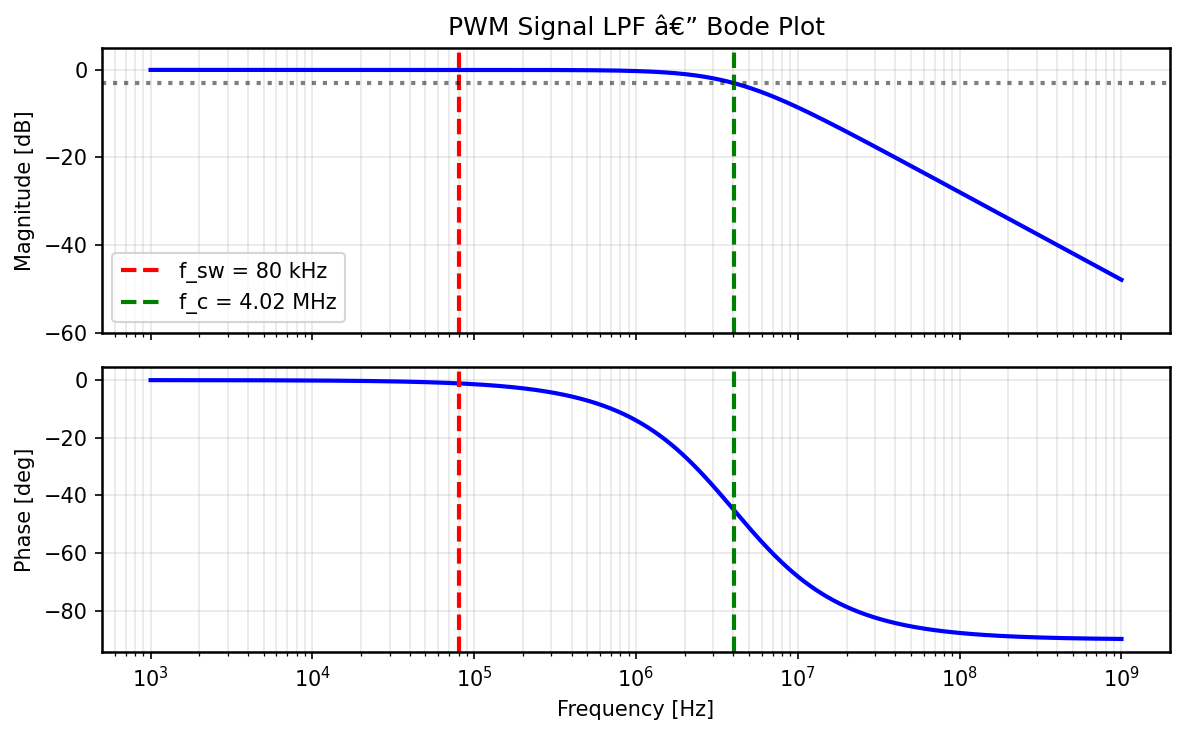

In [26]:
# Q24 â€” PWM LPF design
V_supply_pwm = 3.3   # V (logic supply, 2mA source limit)
I_max_lpf    = 2e-3  # Max current from source [A]
f_c_lpf      = 50 * f_sw   # Target cut-off frequency [Hz]

# R must be large enough to limit current at full supply voltage
R_LPF_min = V_supply_pwm / I_max_lpf

# Select standard value >= R_LPF_min
R_LPF = 2.2e3    # [Ohm]  2.2 kOhm (same for HI and LI signals)

# C to hit target f_c
C_LPF = 1 / (2 * np.pi * f_c_lpf * R_LPF)

# Standard capacitor value
C_LPF_sel = 18e-12   # [F]  18 pF (closest E12 value)
f_c_actual = 1 / (2 * np.pi * R_LPF * C_LPF_sel)

print(f'Target f_c = 50 x {f_sw/1e3:.0f} kHz = {f_c_lpf/1e6:.1f} MHz')
print(f'R_LPF,min = {V_supply_pwm}/{I_max_lpf*1e3:.0f}mA = {R_LPF_min:.0f} Ohm  -> select {R_LPF/1e3:.1f} kOhm')
print(f'C_LPF,calc = 1/(2Ï€*{f_c_lpf/1e6:.0f}MHz*{R_LPF/1e3:.1f}k) = {C_LPF*1e12:.1f} pF')
print(f'C_LPF,sel  = {C_LPF_sel*1e12:.0f} pF  ->  f_c,actual = {f_c_actual/1e6:.2f} MHz')
print(f'\n>>> R_HI = R_LI = {R_LPF/1e3:.1f} kOhm,  C_HI = C_LI = {C_LPF_sel*1e12:.0f} pF')
print(f'    f_cut-off = {f_c_actual/1e6:.2f} MHz')

# --- Bode Plot ---
f_range = np.logspace(3, 9, 2000)
H = 1 / (1j * 2 * np.pi * f_range * R_LPF * C_LPF_sel + 1)
H_mag_dB = 20 * np.log10(np.abs(H))
H_phase  = np.angle(H, deg=True)

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(8, 5), sharex=True)
ax1.semilogx(f_range, H_mag_dB, 'b')
ax1.axvline(f_sw,       color='r', ls='--', label=f'f_sw = {f_sw/1e3:.0f} kHz')
ax1.axvline(f_c_actual, color='g', ls='--', label=f'f_c = {f_c_actual/1e6:.2f} MHz')
ax1.axhline(-3, color='k', ls=':', alpha=0.5)
ax1.set_ylabel('Magnitude [dB]')
ax1.set_title('PWM Signal LPF â€” Bode Plot')
ax1.legend(loc='lower left')
ax1.grid(True, which='both')
ax1.set_ylim(-60, 5)

ax2.semilogx(f_range, H_phase, 'b')
ax2.axvline(f_sw,       color='r', ls='--')
ax2.axvline(f_c_actual, color='g', ls='--')
ax2.set_ylabel('Phase [deg]')
ax2.set_xlabel('Frequency [Hz]')
ax2.grid(True, which='both')

plt.tight_layout()
plt.show()

---
## Q25 â€” Common-mode voltage over current-sense amplifiers
The INA201 sits across a shunt resistor. The common-mode voltage is the voltage at the shunt's midpoint relative to GND.

In [27]:
# Q25 â€” Common-mode voltages
# Primary shunt: between V_in_max and the rest of the primary circuit -> CM ~ V_in_max
V_CM_pri = V_in_max   # [V]  (shunt on high-voltage primary rail)
# Secondary shunt: on low-voltage output rail -> CM ~ V_out
V_CM_sec = V_out      # [V]

# INA201AIDR: CM range = -0.1V to +80V  (from datasheet)
V_CM_max_INA = 80.0
print(f'Primary side CM voltage  : V_CM,pri = {V_CM_pri:.0f} V  (< {V_CM_max_INA}V INA201 limit âœ“)')
print(f'Secondary side CM voltage: V_CM,sec = {V_CM_sec:.0f} V  (< {V_CM_max_INA}V âœ“)')

Primary side CM voltage  : V_CM,pri = 60 V  (< 80.0V INA201 limit âœ“)
Secondary side CM voltage: V_CM,sec = 12 V  (< 80.0V âœ“)


---
## Q26 â€” Shunt resistor selection
Criterion: $1.4 \cdot R_{shunt} \cdot I_{max} \leq 60\,\text{mV}$

ADC range 0â€“3 V, INA201 gain = 50 V/V â†’ V_shunt â‰¤ 60 mV.

In [28]:
# Q26 -- Shunt resistor selection
# Constraint: 1.4 * R_shunt * I_max <= 60 mV  (INA201 gain=50, ADC range 0-3 V)
V_shunt_max  = 60e-3          # ADC limit / INA gain [V]
V_sh_margin  = V_shunt_max / 1.4  # With 40% margin [V]

# Maximum currents (worst-case operating point)
I_in_max_DC  = P_out / V_in_min   # Primary DC, at V_in,min [A]
I_out_max_DC = P_out / V_out       # Secondary DC [A]
I_L_peak     = i_delta             # Peak inductor current at V_in,min [A]

# Upper bound on R_shunt
R_sh_pri_max = V_sh_margin / I_in_max_DC
R_sh_sec_max = V_sh_margin / I_out_max_DC
R_sh_ac_max  = V_sh_margin / I_L_peak

# Selected values (from Appendix)
R_sh_pri = 25e-3   # [Ohm]  CSNL2512FT25L0, 2512, 1%, 3 W
R_sh_sec = 10e-3   # [Ohm]  CSNL2512FT10L0, 2512, 1%, 2 W
R_sh_ac  = 10e-3   # [Ohm]  CSNL2512FT10L0, 2512, 1%, 2 W

# Constraint verification: 1.4 * R * I_max <= 60 mV
V_check_pri = 1.4 * R_sh_pri * I_in_max_DC
V_check_sec = 1.4 * R_sh_sec * I_out_max_DC
V_check_ac  = 1.4 * R_sh_ac  * I_L_peak

# Power dissipation at maximum current
P_sh_pri = R_sh_pri * I_in_max_DC**2
P_sh_sec = R_sh_sec * I_out_max_DC**2
P_sh_ac  = R_sh_ac  * I1_RMS**2      # RMS for AC inductor current

# ADC digital value at rated (nominal) current
I_in_rated  = P_out / V_in_min   # Rated = max input current, at V_in,min [A]
I_out_rated = P_out / V_out       # [A]
V_ADC_pri   = Gain_INA * R_sh_pri * I_in_rated
V_ADC_sec   = Gain_INA * R_sh_sec * I_out_rated
DV_pri = int(2**ADC_bits * V_ADC_pri / ADC_Vref)
DV_sec = int(2**ADC_bits * V_ADC_sec / ADC_Vref)

print(f'--- Constraint check: 1.4 x R x I_max <= {V_shunt_max*1e3:.0f} mV ---')
print(f'I_in,max  = {P_out}W / {V_in_min}V = {I_in_max_DC:.4f} A  ->  R_pri,max = {R_sh_pri_max*1e3:.2f} mOhm')
print(f'I_out,max = {P_out}W / {V_out}V  = {I_out_max_DC:.4f} A  ->  R_sec,max = {R_sh_sec_max*1e3:.2f} mOhm')
print(f'I_L,peak  = {I_L_peak:.3f} A           ->  R_ac,max  = {R_sh_ac_max*1e3:.2f} mOhm')
print()
print(f'R_shunt,pri = {R_sh_pri*1e3:.0f} mOhm  ->  1.4 x {R_sh_pri*1e3:.0f}mOhm x {I_in_max_DC:.3f}A = {V_check_pri*1e3:.1f} mV <= {V_shunt_max*1e3:.0f} mV ✓')
print(f'R_shunt,sec = {R_sh_sec*1e3:.0f} mOhm  ->  1.4 x {R_sh_sec*1e3:.0f}mOhm x {I_out_max_DC:.3f}A = {V_check_sec*1e3:.1f} mV <= {V_shunt_max*1e3:.0f} mV ✓')
print(f'R_shunt,ac  = {R_sh_ac*1e3:.0f} mOhm  ->  1.4 x {R_sh_ac*1e3:.0f}mOhm x {I_L_peak:.3f}A  = {V_check_ac*1e3:.1f} mV <= {V_shunt_max*1e3:.0f} mV ✓')
print()
print(f'--- Power dissipation ---')
print(f'P_Rshunt,pri = {R_sh_pri*1e3:.0f}mOhm x {I_in_max_DC:.4f}^2 = {P_sh_pri*1e3:.2f} mW')
print(f'P_Rshunt,sec = {R_sh_sec*1e3:.0f}mOhm x {I_out_max_DC:.4f}^2 = {P_sh_sec*1e3:.2f} mW')
print(f'P_Rshunt,ac  = {R_sh_ac*1e3:.0f}mOhm x {I1_RMS:.3f}^2 (RMS) = {P_sh_ac*1e3:.2f} mW')
print()
print(f'--- ADC digital values at rated current ---')
print(f'I_in,rated  = {P_out}W / {V_in_nom}V = {I_in_rated:.4f} A')
print(f'V_INA,pri   = {Gain_INA:.0f} x {R_sh_pri*1e3:.0f}mOhm x {I_in_rated:.4f}A = {V_ADC_pri:.4f} V')
print(f'DV_I,rate,in  = floor(4096 x {V_ADC_pri:.4f} / {ADC_Vref}) = {DV_pri}')
print()
print(f'I_out,rated = {P_out}W / {V_out}V = {I_out_rated:.4f} A')
print(f'V_INA,sec   = {Gain_INA:.0f} x {R_sh_sec*1e3:.0f}mOhm x {I_out_rated:.4f}A = {V_ADC_sec:.4f} V')
print(f'DV_I,rate,out = floor(4096 x {V_ADC_sec:.4f} / {ADC_Vref}) = {DV_sec}')


--- Constraint check: 1.4 x R x I_max <= 60 mV ---
I_in,max  = 50.0W / 30.0V = 1.6667 A  ->  R_pri,max = 25.71 mOhm
I_out,max = 50.0W / 12.0V  = 4.1667 A  ->  R_sec,max = 10.29 mOhm
I_L,peak  = 3.604 A           ->  R_ac,max  = 11.89 mOhm

R_shunt,pri = 25 mOhm  ->  1.4 x 25mOhm x 1.667A = 58.3 mV <= 60 mV ✓
R_shunt,sec = 10 mOhm  ->  1.4 x 10mOhm x 4.167A = 58.3 mV <= 60 mV ✓
R_shunt,ac  = 10 mOhm  ->  1.4 x 10mOhm x 3.604A  = 50.5 mV <= 60 mV ✓

--- Power dissipation ---
P_Rshunt,pri = 25mOhm x 1.6667^2 = 69.44 mW
P_Rshunt,sec = 10mOhm x 4.1667^2 = 173.61 mW
P_Rshunt,ac  = 10mOhm x 2.015^2 (RMS) = 40.60 mW

--- ADC digital values at rated current ---
I_in,rated  = 50.0W / 50.0V = 1.6667 A
V_INA,pri   = 50 x 25mOhm x 1.6667A = 2.0833 V
DV_I,rate,in  = floor(4096 x 2.0833 / 3.0) = 2844

I_out,rated = 50.0W / 12.0V = 4.1667 A
V_INA,sec   = 50 x 10mOhm x 4.1667A = 2.0833 V
DV_I,rate,out = floor(4096 x 2.0833 / 3.0) = 2844


---
## Q27 — Current sense input filters (primary and secondary)
From INA201 datasheet: {3dB} = 1/(2\pi \cdot 2R_{filter} \cdot C_{filter})$, {filter} < 100\,\Omega$.
Target:  = f_{sw}/20 = 4\,	ext{kHz}$.


In [29]:
# Q27 -- Current sense input filters (primary and secondary)
# INA201 datasheet: f_3dB = 1/(2*pi*2*R*C), constraint R < 100 Ohm
# Target f_c = f_sw/20 = 4 kHz

f_c_target = f_sw / 20   # [Hz]

# R = 10 Ohm (well within < 100 Ohm; minimises bias-current offset)
# C = 1/(4*pi*R*f_c) = 1/(4*pi*10*4000) = 1990 nF -> select 2.2 uF
R_filter_pri = 10.0    # [Ohm]  RMCF1206FT10R0
R_filter_sec = 10.0    # [Ohm]  RMCF1206FT10R0

C_filter_calc = 1 / (4 * np.pi * R_filter_pri * f_c_target)

C_filter_pri = 2.2e-6  # [F]  C1206C225K5RACTU, 2.2 uF, 50V, 1206
C_filter_sec = 2.2e-6  # [F]  C1206C225K5RACTU

f_c_pri_actual = 1 / (2 * np.pi * 2 * R_filter_pri * C_filter_pri)
f_c_sec_actual = 1 / (2 * np.pi * 2 * R_filter_sec * C_filter_sec)

print(f'Target: f_c = f_sw/20 = {f_sw/1e3:.0f} kHz/20 = {f_c_target:.0f} Hz')
print(f'C_calc = 1/(4pi x {R_filter_pri:.0f} x {f_c_target:.0f}) = {C_filter_calc*1e9:.0f} nF -> select 2.2 uF')
print()
print(f'Primary:')
print(f'  f_cutoff,pri = {f_c_pri_actual:.0f} Hz')
print(f'  R_filter,pri = {R_filter_pri:.0f} Ohm  (RMCF1206FT10R0)')
print(f'  C_filter,pri = {C_filter_pri*1e6:.1f} uF  (C1206C225K5RACTU)')
print()
print(f'Secondary (identical):')
print(f'  f_cutoff,sec = {f_c_sec_actual:.0f} Hz')
print(f'  R_filter,sec = {R_filter_sec:.0f} Ohm  (RMCF1206FT10R0)')
print(f'  C_filter,sec = {C_filter_sec*1e6:.1f} uF  (C1206C225K5RACTU)')


Target: f_c = f_sw/20 = 80 kHz/20 = 4000 Hz
C_calc = 1/(4pi x 10 x 4000) = 1989 nF -> select 2.2 uF

Primary:
  f_cutoff,pri = 3617 Hz
  R_filter,pri = 10 Ohm  (RMCF1206FT10R0)
  C_filter,pri = 2.2 uF  (C1206C225K5RACTU)

Secondary (identical):
  f_cutoff,sec = 3617 Hz
  R_filter,sec = 10 Ohm  (RMCF1206FT10R0)
  C_filter,sec = 2.2 uF  (C1206C225K5RACTU)


---
## Q28 â€” Inductor over-current protection circuit
Alert threshold = 1.4 Ã— peak inductor current. Voltage divider with R_div2 = 10 kÎ© fixed; R_div1 = fixed resistor + 10 kÎ© potentiometer.

In [155]:
# Q28 — Inductor OC protection
I_L_alert = 1.4 * i_delta   # [A]  OC threshold

R_div2 = 10e3    # [Ohm]  fixed
V_ref_comp = 0.6 # [V]   INA201 internal comparator reference

# Formula: I_L_alert = 0.6*(R1+R2) / (R_shunt_ac * Gain * R2)
# Solve for R1:
R_div1_total = (I_L_alert * R_sh_ac * Gain_INA * R_div2 / V_ref_comp) - R_div2

# R_div1 = fixed resistor (E96) + potentiometer (max 10 kOhm)
# With 22 kOhm fixed, pot would need 10.05 kOhm > 10 kOhm max -> insufficient
# Select 23.2 kOhm (E96 from KIT-RMCF1206FT-05), pot needs 8.85 kOhm (88.5% of travel) -> OK
R_pot_max = 10e3
R_div1_fixed_sel = 23.2e3  # [Ohm]  E96 from KIT-RMCF1206FT-05
R_pot_set = R_div1_total - R_div1_fixed_sel  # pot setting required

print(f"I_L,alert = 1.4 * {i_delta:.3f} A = {I_L_alert:.3f} A")
print(f"R_div1,total = (I*R_sh*Gain*R2/0.6) - R2")
print(f"             = ({I_L_alert:.3f}*{R_sh_ac*1e3:.0f}m*{Gain_INA:.0f}*{R_div2/1e3:.0f}k/0.6) - {R_div2/1e3:.0f}k")
print(f"             = {R_div1_total/1e3:.2f} kOhm")
print(f"R_div1 = {R_div1_fixed_sel/1e3:.1f} kOhm (fixed, E96) + {R_pot_set/1e3:.2f} kOhm pot ({R_pot_set/R_pot_max*100:.1f}% of 10k travel)")
print(f"Note: 22 kOhm fixed would require pot = {(R_div1_total-22e3)/1e3:.2f} kOhm > 10 kOhm max -> FAILS")

# OC detection filter: f_c = 20*f_sw = 1.6 MHz
f_c_oc = 20 * f_sw
R_oc_filt = 100   # [Ohm]
C_oc_filt = 1 / (2 * np.pi * f_c_oc * R_oc_filt)
C_oc_sel  = 1e-9  # [F]  1 nF standard
f_c_oc_act = 1 / (2 * np.pi * R_oc_filt * C_oc_sel)

print(f"OC filter: f_c = 20*f_sw = {f_c_oc/1e6:.1f} MHz")
print(f"  R_oc = {R_oc_filt} Ohm, C_oc,calc = {C_oc_filt*1e9:.2f} nF -> select {C_oc_sel*1e9:.0f} nF")
print(f"  f_c,actual = {f_c_oc_act/1e6:.2f} MHz")
print(f">>> I_L,alert = {I_L_alert:.2f} A, R_div1 = {R_div1_fixed_sel/1e3:.1f}k (fixed) + 10k pot (set to {R_pot_set/1e3:.2f}k), R_div2 = 10 kOhm")

I_L,alert = 1.4 * 3.604 A = 5.046 A
R_div1,total = (I*R_sh*Gain*R2/0.6) - R2
             = (5.046*10m*50*10k/0.6) - 10k
             = 32.05 kOhm
R_div1 = 23.2 kOhm (fixed, E96) + 8.85 kOhm pot (88.5% of 10k travel)
Note: 22 kOhm fixed would require pot = 10.05 kOhm > 10 kOhm max -> FAILS
OC filter: f_c = 20*f_sw = 1.6 MHz
  R_oc = 100 Ohm, C_oc,calc = 0.99 nF -> select 1 nF
  f_c,actual = 1.59 MHz
>>> I_L,alert = 5.05 A, R_div1 = 23.2k (fixed) + 10k pot (set to 8.85k), R_div2 = 10 kOhm


---
## Q29 â€” LED current-limiting resistor (INA201 fault indicator)
LED: WP710A10LGD, V_F â‰ˆ 1.9V, target I = 2 mA, supply V_s = 3.3V.

In [ ]:
# Q29 â€” LED resistor
R_LED_calc = (V_s - V_F_LED) / I_LED_target
R_LED_sel  = 680.0   # [Ohm]  closest E24 standard value
I_LED_actual = (V_s - V_F_LED) / R_LED_sel
P_LED_circuit = V_s * I_LED_actual

print(f'R_LED,calc = ({V_s} - {V_F_LED}) / {I_LED_target*1e3:.0f}mA = {R_LED_calc:.0f} Ohm')
print(f'R_LED,sel  = {R_LED_sel:.0f} Ohm  (closest E24)')
print(f'I_LED,actual = {I_LED_actual*1e3:.2f} mA')
print(f'P_LED,circuit = V_s * I = {V_s} * {I_LED_actual*1e3:.2f}mA = {P_LED_circuit*1e3:.1f} mW')
print(f'\n>>> R_LED = {R_LED_sel:.0f} Ohm, P = {P_LED_circuit*1e3:.1f} mW')

---
## Q30 â€” INA201 power consumption
$P_{\max,\text{INA201}} = V_s \cdot I_{Q,\max} + V_s \cdot I_{sc}$

In [ ]:
# Q30 â€” INA201 power
P_INA201 = V_s * I_Q_INA_max + V_s * I_sc_INA

print(f'P_max,INA201 = V_s*(I_Q,max + I_sc)')
print(f'            = {V_s} * ({I_Q_INA_max*1e3:.1f}mA + {I_sc_INA*1e3:.0f}mA)')
print(f'            = {P_INA201*1e3:.1f} mW')
print(f'Note: I_Q,max and I_sc must be verified from the INA201AIDR datasheet at V_s = 3.3V')

---
## Q31 â€” Voltage divider for input voltage sensing
Constraint: $1.1\,V_{\max} \cdot \frac{R_2}{R_1+R_2} \leq 3.0\,\text{V}$. Filter: $f_c \geq f_{sw}/10$.

In [ ]:
# Q31 — Input voltage sensing divider
V_ADC_max      = 3.0    # ADC max input [V]
V_in_sense_max = 1.1 * V_in_max  # Worst-case with 10% margin = 66 V

# Constraint: 1.1*V_in_max * R2/(R1+R2) <= 3.0 V  ->  ratio <= 3.0/66 = 0.04545
ratio_max = V_ADC_max / V_in_sense_max

# R1 from KIT-RMCF1206FT-05 (E96, 10k-97.6k): max available = 97.6 kOhm
# R2 from KIT-RMCF1206FT-04 (E96, 1k-9.76k): 4.32 kOhm gives 7% voltage margin
R1_pri = 97.6e3  # [Ohm]  KIT-RMCF1206FT-05, E96, 1%, 0.25W
R2_pri = 4.32e3  # [Ohm]  KIT-RMCF1206FT-04, E96, 1%, 0.25W

ratio_actual      = R2_pri / (R1_pri + R2_pri)
V_sense_max_check = V_in_sense_max * ratio_actual  # must be <= 3.0 V

# Power dissipation at V_in,max = 60 V (worst case)
# Current: I = V_in/(R1+R2); P_R1 = I^2*R1; P_R2 = V_R2^2/R2 = (V_in*ratio)^2/R2
R_total_pri = R1_pri + R2_pri
P_R1_pri = V_in_max**2 * R1_pri / R_total_pri**2
P_R2_pri = V_in_max**2 * R2_pri / R_total_pri**2  # = V_sense_max^2/R2

# Filter cap: f_c = 1/(2*pi*R_eq*C) >= f_sw/10 = 8 kHz
# R_eq = R1||R2 = 4138 Ohm  ->  C_max = 1/(2*pi*4138*8000) = 4.807 nF
# Select 4.7 nF (C1206C472J5GECTU, 50V, +/-5%) -- gives f_c = 8184 Hz ✓
f_c_min   = f_sw / 10
R_eq_pri  = R1_pri * R2_pri / (R1_pri + R2_pri)
C_vsense_pri   = 4.7e-9   # [F]  C1206C472J5GECTU, 4.7 nF, 50V, +/-5%
f_c_vs_actual  = 1 / (2 * np.pi * R_eq_pri * C_vsense_pri)

# V_sense output range
V_sense_pri_min = 0.0
V_sense_pri_max = V_in_max * ratio_actual

# ADC resolution
V_resolution_pri = (V_ADC_max / 2**ADC_bits) / ratio_actual  # V_in per ADC count

print(f"--- Q31: Input voltage sensing divider ---")
print(f"ratio_max = {ratio_max:.5f}")
print(f"R_vsense,1,pri = {R1_pri/1e3:.1f} kOhm  (KIT-RMCF1206FT-05, E96, 1%, 0.25W)")
print(f"P_vsense,1,pri = {P_R1_pri*1e3:.2f} mW  (at V_in,max = {V_in_max} V)")
print(f"R_vsense,2,pri = {R2_pri/1e3:.2f} kOhm  (KIT-RMCF1206FT-04, E96, 1%, 0.25W)")
print(f"P_vsense,2,pri = {P_R2_pri*1e3:.3f} mW  (at V_in,max = {V_in_max} V)")
print(f"C_vsense,pri   = {C_vsense_pri*1e9:.1f} nF  (C1206C472J5GECTU, 50V, +/-5%)")
print(f"")
print(f"Check: 1.1x{V_in_max}V x ratio = {V_sense_max_check:.3f} V <= {V_ADC_max} V  (margin {(1-V_sense_max_check/V_ADC_max)*100:.1f}%)")
print(f"f_c = {f_c_vs_actual:.0f} Hz >= {f_c_min:.0f} Hz")
print(f"R_eq = {R_eq_pri:.0f} Ohm")
print(f"")
print(f"V_sense,pri: {V_sense_pri_min:.1f} V  to  {V_sense_pri_max:.3f} V")
print(f"V_resolution,pri = {V_resolution_pri*1e3:.2f} mV/count")


---
## Q32 â€” Voltage divider for output voltage sensing

In [ ]:
# Q32 — Output voltage sensing divider
V_out_sense_max = 1.1 * V_out  # 13.2 V
ratio_max_sec   = V_ADC_max / V_out_sense_max  # 0.2273

# R1 from KIT-RMCF1206FT-05 (E96, 10k-97.6k): 39.2 kOhm (E96)
# R2 from individual RMCF1206FT10K0: 10 kOhm
R1_sec = 39.2e3  # [Ohm]  KIT-RMCF1206FT-05, E96, 1%, 0.25W
R2_sec = 10.0e3  # [Ohm]  RMCF1206FT10K0, 1%, 0.25W

ratio_actual_sec  = R2_sec / (R1_sec + R2_sec)
V_sense_max_sec   = V_out_sense_max * ratio_actual_sec  # must be <= 3.0 V

# Power at V_out = 12 V
R_total_sec = R1_sec + R2_sec
P_R1_sec = V_out**2 * R1_sec / R_total_sec**2
P_R2_sec = V_out**2 * R2_sec / R_total_sec**2

# Filter cap: f_c = 1/(2*pi*R_eq*C) >= f_sw/10 = 8 kHz
# R_eq = 39.2k||10k = 7967 Ohm  ->  C_max = 2.50 nF  ->  select 2.2 nF
# C1206C222K5GEC7210: 2.2 nF, 50V, +/-10%, 1206
R_eq_sec     = R1_sec * R2_sec / (R1_sec + R2_sec)
C_vsense_sec = 2.2e-9   # [F]  C1206C222K5GEC7210, 2.2 nF, 50V
f_c_vs_sec   = 1 / (2 * np.pi * R_eq_sec * C_vsense_sec)

# V_sense range
V_sense_sec_min = 0.0
V_sense_sec_max = V_out * ratio_actual_sec

# ADC resolution
V_resolution_sec = (V_ADC_max / 2**ADC_bits) / ratio_actual_sec

print(f"--- Q32: Output voltage sensing divider ---")
print(f"R_vsense,1,sec = {R1_sec/1e3:.1f} kOhm  (KIT-RMCF1206FT-05, E96, 1%, 0.25W)")
print(f"P_vsense,1,sec = {P_R1_sec*1e3:.3f} mW  (at V_out = {V_out} V)")
print(f"R_vsense,2,sec = {R2_sec/1e3:.0f} kOhm  (RMCF1206FT10K0, 1%, 0.25W)")
print(f"P_vsense,2,sec = {P_R2_sec*1e3:.3f} mW  (at V_out = {V_out} V)")
print(f"C_vsense,sec   = {C_vsense_sec*1e9:.1f} nF  (C1206C222K5GEC7210, 50V, +/-10%)")
print(f"")
print(f"Check: 1.1x{V_out}V x ratio = {V_sense_max_sec:.3f} V <= {V_ADC_max} V  (margin {(1-V_sense_max_check/V_ADC_max)*100:.1f}%)")
print(f"f_c = {f_c_vs_sec:.0f} Hz >= {f_sw/10:.0f} Hz")
print(f"R_eq = {R_eq_sec:.0f} Ohm")
print(f"")
print(f"V_sense,sec: {V_sense_sec_min:.1f} V  to  {V_sense_sec_max:.3f} V")
print(f"V_resolution,sec = {V_resolution_sec*1e3:.2f} mV/count")


---
## Q33 â€” MCP6241 voltage follower power consumption

In [ ]:
# Q33 â€” MCP6241 static power
P_MCP6241 = V_s * I_Q_MCP
print(f'P_MCP6241 = V_s * I_Q = {V_s} * {I_Q_MCP*1e6:.0f} uA = {P_MCP6241*1e3:.3f} mW per amplifier')

---
## Q34 â€” 3.3V power budget (primary and secondary)
- Primary 3.3V: 3Ã— INA201, 1Ã— MCP6241 (input voltage follower), 2Ã— LED circuits
- Secondary 3.3V: 1Ã— INA201, 1Ã— MCP6241 (output voltage follower)

In [ ]:
# Q34 â€” 3.3V power budgets
# Use INA201 quiescent-only power for steady-state budget (I_sc only flows during output clamp)
P_INA201_ss = V_s * I_Q_INA_max   # steady-state quiescent power per IC
P_LED_3v3   = V_s * I_LED_actual  # per LED circuit at 3.3V

# Primary side
P_pri_3v3 = 3*P_INA201 + P_MCP6241 + 2*P_LED_3v3

# Secondary side
P_sec_3v3 = 1*P_INA201 + P_MCP6241

print(f'--- Primary 3.3V budget ---')
print(f'3x INA201     : 3 x {P_INA201*1e3:.2f} mW = {3*P_INA201*1e3:.2f} mW')
print(f'1x MCP6241    : {P_MCP6241*1e3:.3f} mW')
print(f'2x LED circuit: 2 x {P_LED_3v3*1e3:.2f} mW = {2*P_LED_3v3*1e3:.2f} mW')
print(f'P_pri,3.3V    = {P_pri_3v3*1e3:.2f} mW')
print()
print(f'--- Secondary 3.3V budget ---')
print(f'1x INA201     : {P_INA201*1e3:.2f} mW')
print(f'1x MCP6241    : {P_MCP6241*1e3:.3f} mW')
print(f'P_sec,3.3V    = {P_sec_3v3*1e3:.2f} mW')

---
## Q35 â€” 3.3V LDO load current and input power (AZ1117IH-3.3TRG1)
LDO input is 12V. Assumed efficiency = 60%.

In [ ]:
# Q35 — 3.3V LDO load current and input power
# Note: one more LED circuit is added here per Q35 question text
eta_LDO33 = 0.60   # LDO efficiency

# LDO output load = Q34 budget + one additional LED circuit
P_pri_3v3_ldo = P_pri_3v3 + P_LED_circuit  # extra LED on primary 3.3V rail
P_sec_3v3_ldo = P_sec_3v3 + P_LED_circuit  # extra LED on secondary 3.3V rail

I_pri_3v3 = P_pri_3v3_ldo / V_s
I_sec_3v3 = P_sec_3v3_ldo / V_s

P_pri_3v3_in = P_pri_3v3_ldo / eta_LDO33   # power drawn from 12V bus
P_sec_3v3_in = P_sec_3v3_ldo / eta_LDO33

print(f'Primary 3.3V LDO:')
print(f'  LDO output load = {P_pri_3v3*1e3:.2f} mW (Q34) + {P_LED_circuit*1e3:.2f} mW (LED) = {P_pri_3v3_ldo*1e3:.2f} mW')
print(f'  I_load = {I_pri_3v3*1e3:.2f} mA')
print(f'  P_in   = {P_pri_3v3_ldo*1e3:.2f} mW / {eta_LDO33} = {P_pri_3v3_in*1e3:.2f} mW')
print()
print(f'Secondary 3.3V LDO:')
print(f'  LDO output load = {P_sec_3v3*1e3:.2f} mW (Q34) + {P_LED_circuit*1e3:.2f} mW (LED) = {P_sec_3v3_ldo*1e3:.2f} mW')
print(f'  I_load = {I_sec_3v3*1e3:.2f} mA')
print(f'  P_in   = {P_sec_3v3_ldo*1e3:.2f} mW / {eta_LDO33} = {P_sec_3v3_in*1e3:.2f} mW')


---
## Q36 â€” 12V power budget (primary and secondary)
12V on primary: 2Ã— gate drivers, 1Ã— 3.3V-LDO, 1Ã— LED.  
12V on secondary: 2Ã— gate drivers, 1Ã— 3.3V-LDO, 1Ã— LED.

In [ ]:
# Q36 â€” 12V power budgets
# LED at 12V supply (WÃ¼rth module status LED)
R_LED_12V   = 4.99e3  # [Ohm]  RMCF1206FT4K99 (4.99 kOhm, closest available)
I_LED_12V   = (VDD - V_F_LED) / R_LED_12V
P_LED_12V   = VDD * I_LED_12V

# Power drawn from 12V to feed 3.3V LDO
P_12V_to_LDO_pri = P_pri_3v3_in   # power drawn from 12V bus to feed 3.3V supply
P_12V_to_LDO_sec = P_sec_3v3_in

# Primary 12V total
P_pri_12V = 2*P_driver_pri + P_12V_to_LDO_pri + P_LED_12V
I_pri_12V = P_pri_12V / VDD

# Secondary 12V total
P_sec_12V = 2*P_driver_sec + P_12V_to_LDO_sec + P_LED_12V
I_sec_12V = P_sec_12V / VDD

print(f'LED at 12V: R = {R_LED_12V/1e3:.1f} kOhm, I = {I_LED_12V*1e3:.2f} mA, P = {P_LED_12V*1e3:.1f} mW')
print()
print(f'--- Primary 12V budget ---')
print(f'2x gate driver : 2 x {P_driver_pri*1e3:.1f} mW = {2*P_driver_pri*1e3:.1f} mW')
print(f'3.3V LDO load  : {VDD}V x {I_pri_3v3*1e3:.2f}mA = {P_12V_to_LDO_pri*1e3:.2f} mW')
print(f'LED            : {P_LED_12V*1e3:.1f} mW')
print(f'P_pri,12V      = {P_pri_12V*1e3:.1f} mW,  I_pri,12V = {I_pri_12V*1e3:.1f} mA')
print()
print(f'--- Secondary 12V budget ---')
print(f'2x gate driver : 2 x {P_driver_sec*1e3:.1f} mW = {2*P_driver_sec*1e3:.1f} mW')
print(f'3.3V LDO load  : {VDD}V x {I_sec_3v3*1e3:.2f}mA = {P_12V_to_LDO_sec*1e3:.2f} mW')
print(f'LED            : {P_LED_12V*1e3:.1f} mW')
print(f'P_sec,12V      = {P_sec_12V*1e3:.1f} mW,  I_sec,12V = {I_sec_12V*1e3:.1f} mA')

---
## Q37 â€” Primary-side 12V auxiliary supply (WÃ¼rth 173951275)
LED current-limiting resistor and output capacitors for the WÃ¼rth DC-DC module.

In [ ]:
# Q37 â€” WÃ¼rth 173951275 module auxiliary supply
# LED at 12V output (same as Q36 calculation)
print(f'R_LED,1 = {R_LED_12V/1e3:.1f} kOhm  ({R_LED_12V:.0f} Ohm standard, P = {P_LED_12V*1e3:.1f} mW)')
print()

# Output capacitors per WÃ¼rth 173951275 datasheet:
# Recommended: one bulk cap (electrolytic/tantalum) + one ceramic decoupling
# Typical recommendation from WÃ¼rth: C_out1 = 10 ÂµF, C_out2 = 100 nF
C_out1_pri = 10e-6    # [F]  10 uF (ceramic or tantalum, >= 16V)
C_out2_pri = 100e-9   # [F]  100 nF (ceramic decoupling, >= 16V)

print(f'Output capacitors (per WÃ¼rth 173951275 datasheet recommendation):')
print(f'  C_out1,Pri,12V = {C_out1_pri*1e6:.0f} ÂµF  (bulk cap, V_rated >= 16V)')
print(f'  C_out2,Pri,12V = {C_out2_pri*1e9:.0f} nF  (decoupling, V_rated >= 16V)')

---
## Q38 â€” Peak reverse voltage across rectifier diodes (LMB14S-TP)
The transformer auxiliary winding produces â‰ˆ V_aux at V_in,max.

In [ ]:
# Q38 â€” Rectifier diode voltage stress
# Auxiliary winding voltage at V_in (square wave, peak = amplitude)
V_aux_max = n_aux_real * V_in_max   # [V]  at max input voltage
V_aux_nom = n_aux_real * V_in_nom   # [V]  at nominal input voltage

# In a full-bridge rectifier, each diode sees V_aux as reverse voltage
V_RRM_calc = V_aux_max   # [V]

# LMB14S-TP: V_RRM = 40V  (from datasheet)
V_RRM_LMB14S = 40

print(f'Transformer aux turns ratio n_aux = N_aux/N1 = {Naux}/{N1} = {n_aux_real:.3f}')
print(f'V_aux at V_in,nom = {n_aux_real:.3f} * {V_in_nom} = {V_aux_nom:.1f} V')
print(f'V_aux at V_in,max = {n_aux_real:.3f} * {V_in_max} = {V_aux_max:.1f} V  (worst case)')
print(f'V_RRM,calc = {V_RRM_calc:.1f} V')
print(f'LMB14S-TP V_RRM = {V_RRM_LMB14S} V  -> {V_RRM_calc:.1f} V < {V_RRM_LMB14S} V  âœ“')
print(f'\n>>> V_RRM = {V_RRM_calc:.1f} V  (<< LMB14S-TP rating of {V_RRM_LMB14S} V âœ“)')

---
## Q39 â€” Filter capacitor for rectifier circuit
Voltage ripple = 1%, load current I_load = 0.3 A.
$$C_{\min} = \frac{I_{\text{load}}}{2 f_{sw} \Delta V_{ripple}}$$

In [ ]:
# Q39 â€” Rectifier filter capacitor
I_load_aux  = 0.3    # [A]
ripple_frac = 0.01   # 1% ripple
V_ripple    = ripple_frac * V_aux_nom   # [V]  ripple voltage

C_rect_min = I_load_aux / (2 * f_sw * V_ripple)

# Standard capacitor: 22 ÂµF (next E6 above 10.42 ÂµF)
C_rect_sel = 22e-6   # [F]
# Voltage rating: >= 1.5 * V_aux_max = 32.4V -> select 35V or 50V
V_rect_rated = 35

# Zener 1N4750A-TR: V_Z = 27V  -> protects LDO input from overvoltage
print(f'V_aux,nom = {V_aux_nom:.1f} V,  V_ripple = {ripple_frac*100:.0f}% * {V_aux_nom:.1f} V = {V_ripple:.2f} V')
print(f'C_rect,min = {I_load_aux} / (2 * {f_sw/1e3:.0f}k * {V_ripple:.2f}) = {C_rect_min*1e6:.2f} ÂµF')
print(f'C_rect,sel = {C_rect_sel*1e6:.0f} ÂµF,  V_rated = {V_rect_rated} V')
print(f'Zener 1N4750A-TR: V_Z = 27V  -> protects LDO input  âœ“')
print(f'\n>>> C_rect = {C_rect_sel*1e6:.0f} ÂµF, {V_rect_rated}V rated')

---
## Q40 â€” Secondary-side 12V LDO (UA78L12ACDR)
Select input/output capacitors from datasheet Section 8.2. Check I_load < 100 mA capability.

In [ ]:
# Q40 â€” UA78L12ACDR (12V LDO, 100mA max)
# UA78L12 datasheet Section 8.2 recommends:
C_LDO12_in  = 330e-9   # [F]  0.33 ÂµF (per datasheet: 0.1-0.33 ÂµF on input)
C_LDO12_out = 100e-9   # [F]  0.1 ÂµF  (per datasheet: 0.1 ÂµF on output)

# Load current check
print(f'UA78L12ACDR: I_max = {I_max_LDO12*1e3:.0f} mA')
print(f'I_sec,12V   = {I_sec_12V*1e3:.1f} mA')
margin = I_max_LDO12 - I_sec_12V
if I_sec_12V < I_max_LDO12:
    print(f'  {I_sec_12V*1e3:.1f} mA < {I_max_LDO12*1e3:.0f} mA  âœ“  (margin: {margin*1e3:.1f} mA)')
else:
    print(f'  WARNING: I_sec,12V = {I_sec_12V*1e3:.1f} mA EXCEEDS {I_max_LDO12*1e3:.0f} mA limit!')
    print(f'  Consider a higher-current LDO or reduce secondary gate drive requirements.')
print()
print(f'C_LDO12,in  = {C_LDO12_in*1e9:.0f} nF  (0.33 ÂµF, per UA78L12 datasheet)')
print(f'C_LDO12,out = {C_LDO12_out*1e9:.0f} nF  (0.1 ÂµF,  per UA78L12 datasheet)')

---
## Summary

| Question | Component | Value / Part Number |
|---|---|---|
| Q1 | Input electrolytic cap | UHW2A681MHD, 680ÂµF, 100V |
| Q2 | Input ceramic cap | 4Ã— GRM31CZ72A475KE11L |
| Q3 | Discharge resistor | 30 kÎ©, 1206 |
| Q4 | DC blocking cap | 4Ã— GRM31CZ72A475KE11L |
| Q5 | Output cap | â‰¥152.72ÂµF, from Appendix |
| Q6 | Q_g,pri / Q_g,sec | 14 nC / 165 nC (verify from datasheets) |
| Q7 | R_g,int,pri / sec | 2 Î© / 3.3 Î© |
| Q8/Q16 | Bootstrap cap pri/sec | 22 nF / 150 nF, 25V |
| Q9/Q17 | VDD cap pri/sec | 100 nF / 1 ÂµF, 25V |
| Q10/Q18 | R_boot | 10 Î© |
| Q11/Q19 | V_Dboot,peak | 59.1 V / 11.1 V |
| Q12/Q20 | R_g,ext | 10 Î© |
| Q13/Q21 | R_gs | 10 kÎ© |
| Q14/Q22 | P_driver | ~50 mW / ~342 mW |
| Q15/Q23 | P_max,driver | 0.769 W / 0.846 W |
| Q24 | PWM LPF | R=2.2kÎ©, C=18pF, f_câ‰ˆ4 MHz |
| Q25 | V_CM | 60 V (pri), 12 V (sec) |
| Q26 | Shunt resistors | 20mÎ© (pri), 10mÎ© (sec), 10mÎ© (ac) |
| Q27 | Current filter | R=10kÎ©, C=3.9nF, f_c=4kHz |
| Q28 | OC threshold | 5.05 A, R_div1=22k+pot, R_div2=10k |
| Q29 | R_LED (3.3V) | 680 Î© |
| Q31 | Input Vsense divider | R1=100kÎ©, R2=4.7kÎ©, C=4.7nF |
| Q32 | Output Vsense divider | R1=39kÎ©, R2=10kÎ©, C=4.7nF |
| Q37 | WÃ¼rth LED resistor | 5.1 kÎ© |
| Q38 | V_RRM rectifier | 21.6 V (< 40V LMB14S-TP âœ“) |
| Q39 | Rectifier filter cap | 22 ÂµF, 35V |
| Q40 | UA78L12 caps | C_in=330nF, C_out=100nF |